# $$ \textbf{Sinais e Sistemas Dinâmicos}$$


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia [Sinais e Sistemas Lineates, B. P. Lathi; 2. ed. Porto Alegre: Bookman, 2008.]. 

Quando aplicável, utilizaremos a  biblioteca de computação simbólica *sympy* (e mais algumas que se fizerem necessárias) do Python.



In [4]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

## Revisão

Antes de darmos início aos nossos estudos de Sinais e Sistemas Dinâmicos, vamos fazer uma breve revisão de alguns conteúdos importantes que serão úteis em abordagens posteriores. 


### 1. Números Complexos

 - **Obs 1**: vamos utilizar a letra $j$ (ou $J$) para números complexos, ao invés da costumaz letra $i$ que também é utilizada para denotar corrente elétrica. Tal notação é compatível com a linguagem Python (que demanda a importação da biblioteca "cmath") e é usual nas engenharias elétrica e da computação.

Abaixo apresentamos alguns exemplos em Python.

 - **Obs 2**: deve-se notar que em Python é necessário utilizar a biblioteca **cmath** e que $j$ deve ser necessariamente representado por $1j$.

In [3]:
j**2

NameError: name 'j' is not defined

In [ ]:
1j**2

(-1+0j)

A letra $I$ é uma alternativa

In [ ]:
I**2

-1

In [ ]:
[(1J**2).real, (1J**2).imag]

[-1.0, 0.0]

Um número complexo pode ser criado como 

In [ ]:
2 + 3j

(2+3j)

ou, através da função **complex(a,b)**, que cria o número complexo $a + bj$,

In [ ]:
complex(2,3)

(2+3j)

In [ ]:
2 + 3*I

2 + 3*I

#### Álgebra dos Números Complexos


O número complexo $(a, b)$ ou $a+j b$ pode ser representado graficamente por um ponto cujas coordenadas cartesianas são $(a, b)$ em um plano complexo. 

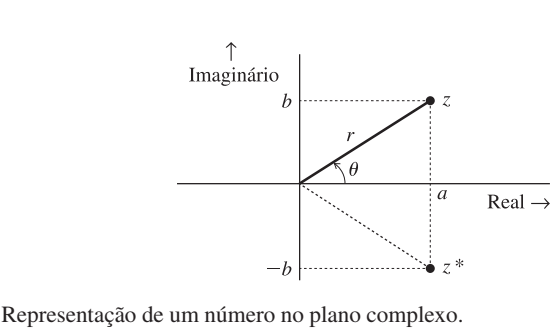



Vamos chamar esse número complexo de $z$, tal que
$$
z=a+j b
$$
Os números $a$ e $b$ (a abscissa e a ordenada) de $z$ são a parte real e a parte imaginária, respectivamente, de $z$. Eles também podem ser expressos por
$$
\begin{aligned}
& \operatorname{Re} z=a \\
& \operatorname{Im} z=b
\end{aligned}
$$
Note que neste plano todos os números reais permanecem no eixo horizontal e todos os números imaginários permanecem no eixo vertical.

Os números complexos também pode ser expressos em termos de coordenadas polares. Se $(r, \theta)$ são as coordenadas polares de um ponto $z=a+j b$ (veja figura acima), então
$$
\begin{aligned}
& a=r \cos \theta \\
& b=r \operatorname{sen} \theta
\end{aligned}
$$


e
$$
\begin{aligned}
z=a+j b & =r \cos \theta+j r \operatorname{sen} \theta \\
& =r(\cos \theta+j \operatorname{sen} \theta)
\end{aligned}
$$

A **fórmula de Euler** afirma que
$$
e^{j \theta}=\cos \theta+j \operatorname{sen} \theta
$$
Para provar a fórmula de Euler, utilizamos a série de Maclaurin para expandir $e^{j \theta}, \cos \theta$ e sen $\theta$ :
$$
\begin{aligned}
e^{j \theta} & =1+j \theta+\frac{(j \theta)^2}{2 !}+\frac{(j \theta)^3}{3 !}+\frac{(j \theta)^4}{4 !}+\frac{(j \theta)^5}{5 !}+\frac{(j \theta)^6}{6 !}+\cdots \\
& =1+j \theta-\frac{\theta^2}{2 !}-j \frac{\theta^3}{3 !}+\frac{\theta^4}{4 !}+j \frac{\theta^5}{5 !}-\frac{\theta^6}{6 !}-\cdots \\
\cos \theta & =1-\frac{\theta^2}{2 !}+\frac{\theta^4}{4 !}-\frac{\theta^6}{6 !}+\frac{\theta^8}{8 !} \cdots \\
\operatorname{sen} \theta & =\theta-\frac{\theta^3}{3 !}+\frac{\theta^5}{5 !}-\frac{\theta^7}{7 !}+\cdots
\end{aligned}
$$
Portanto, temos que
$$
e^{j \theta}=\cos \theta+j \operatorname{sen} \theta
$$

Assim,
$$
\begin{aligned}
z & =a+j b \\
& =r e^{j \theta}
\end{aligned}
$$
Portanto, um número complexo pode ser expresso na **forma cartesiana** $a+j b$ ou na **forma polar** $r e^{j \theta}$, sendo
$$
a=r \cos \theta, \quad b=r \operatorname{sen} \theta
$$
e
$$
r=\sqrt{a^2+b^2}, \quad \theta=\tan ^{-1}\left(\frac{b}{a}\right)
$$
Observe que $r$ é a distância do ponto $z$ a origem. Por esta razão, $r$ é chamado de **módulo** (ou **valor absoluto**) de $z$, sendo representado por $|z|$. Similarmente, $\theta$ é chamado de **ângulo** (**argumento** ou **fase**) de $z$ e representado por $\angle z$. 

Portanto,
$$
|z|=r, \quad \angle z=\theta
$$
$$
z=|z| e^{j \angle z}
$$
Tem-se também,
$$
\frac{1}{z}=\frac{1}{r e^{j \theta}}=\frac{1}{r} e^{-j \theta}=\frac{1}{|z|} e^{-j \angle z}
$$


In [ ]:
# O módulo de um número complexo pode ser calculado usando a função padrão abs() 
abs(complex(1.0, 1.0))

1.4142135623730951

In [ ]:
# A fase pode ser calculada usando phase().
cmath.phase(complex(1.0, 1.0))

0.7853981633974483

In [ ]:
'''Podemos converter um número complexo usando da forma Cartesiana para polar, 
usando polar(z), que retornará um par (r, phi), onde r é abs(z) e phi é phase(z).'''

cmath.polar(complex(1.0, 1.0))

(1.4142135623730951, 0.7853981633974483)

In [ ]:
'''Similarmente, convertemos um número complexo da forma polar para Cartesiana usando rect(r, phi). 
O número complexo retornado será r * (math.cos(phi) + math.sin(phi)*1j).'''

cmath.rect(1.4142135623730951, 0.7853981633974483)

(1.0000000000000002+1.0000000000000002j)

#### 1.1 Conjugado de um número complexo

Define-se $z^*$, o conjugado de $z=a+j b$ por
$$
\begin{aligned}
z^*= & a-j b=r e^{-j \theta} \\
& =|z| e^{-j \angle z}
\end{aligned}
$$
A representação gráfica de um número $z$ e seu conjugado $z^*$ é mostrada na figura abaixo. 

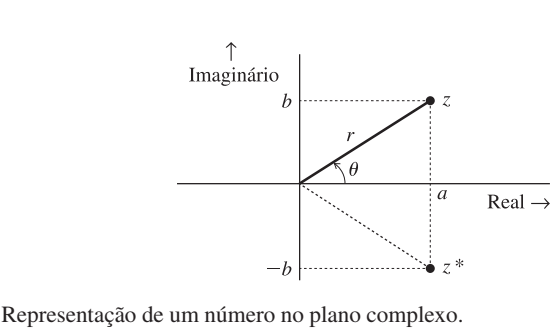


Observe que $z^*$ é uma imagem refletida de $z$ com relação ao eixo horizontal. Para determinar o conjugado de qualquer número, precisamos apenas substituir $j$ por  $- j$ no número (sendo o mesmo que alterar o sinal de seu ângulo).

A soma de um número complexo com o seu conjugado é um número real igual a duas vezes a parte real do número.
$$
z+z^*=(a+j b)+(a-j b)=2 a=2 \operatorname{Re} z
$$
O Produto de um número complexo $z$ por seu conjugado é um número real $|z|^2$, o quadrado do módulo do número:
$$
z z^*=(a+j b)(a-j b)=a^2+b^2=|z|^2
$$

A função **conj()** (do módulo numpy) fornece o **conjugado**

In [ ]:
np.conj(complex(2,3))

(2-3j)

note, que

In [ ]:
z = complex(3,4)
z + np.conj(z)

(6+0j)

e que 

In [ ]:
z * np.conj(z)

(25+0j)

In [ ]:
sqrt(z * np.conj(z))

5.00000000000000

que é equivalente a

In [ ]:
abs(z)

5.0

Finalmente, para a representação gráfica, temos o seguinte exemplo

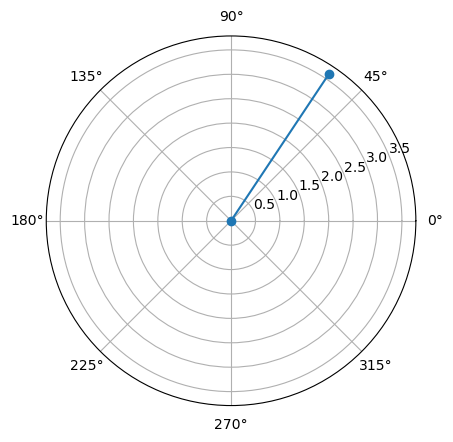

In [ ]:
x= complex(2,3)
plt.polar([0,np.angle(x)],[0,np.abs(x)],marker='o')

#### 1.2 Compreendendo algumas identidades úteis

No plano complexo, $r e^{j \theta}$ representa um ponto a uma distância $r$ da origem e com um ângulo $\theta$ do eixo horizontal, como mostrado na figura (a). 


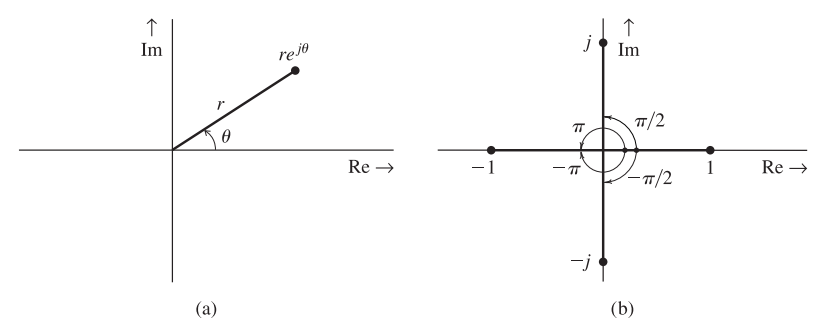

Por exemplo, o número -1 está a uma distância unitária da origem e possui um ângulo $\pi$ ou $-\pi$ (de fato, qualquer múltiplo ímpar de $\pm \pi$ ), como visto na figura (b).

Portanto,
$$
1 e^{ \pm j \pi}=-1
$$
de fato,
$$
e^{ \pm j n \pi}=-1 \quad n, \text{inteiro ímpar.}
$$
O número 1 , por outro lado, também está a uma distância unitária da origem, mas possui ângulo $2 \pi$ (de fato, $\pm 2 n \pi$, para qualquer valor inteiro de $n$ ). Portanto,
$$
e^{ \pm j 2 n \pi}=1, \quad n \text { inteiro.}
$$

Note que podemos escrever de forma geral
$$
e^{ \pm j n \pi} = (-1)^n,  \quad n \text { inteiro.}
$$

O número $j$ está a uma distância unitária da origem e seu ângulo é $\pi / 2$ - veja figura (b). Portanto,
$$
e^{j \pi / 2}=j
$$

Similarmente,
$$
e^{-j \pi / 2}=-j
$$
Logo,
$$
e^{ \pm j \pi / 2}= \pm j
$$

De fato,
$$
e^{ \pm j n \pi / 2}= \begin{cases} \pm j & n=1,5,9,13, \ldots \\ \mp j & n=3,7,11,15, \ldots\end{cases}
$$

Esta discussão mostra a utilidade do gráfico de $r e^{j \theta}$. 

Esta figura também é útil em várias outras aplicações. Por exemplo, para determinar o limite de $e^{(\alpha+j \omega) t}$, quando $t \rightarrow \infty$, observamos que
$$
e^{(\alpha+j \omega) t}=e^{\alpha t} e^{j \omega t}
$$

Agora, o módulo de $e^{j \omega t}$ é unitário, independente do valor de $\omega$ ou $t$, pois $e^{j \omega t}=r e^{j \theta} \operatorname{com} r=1$. 

Portanto, $e^{\alpha t}$ determina o comportamento de $e^{(a+j \omega) t}$, quando $t \rightarrow \infty$, e
$$
\lim _{t \rightarrow \infty} e^{(\alpha+j \omega) t}=\lim _{t \rightarrow \infty} e^{\alpha t} e^{j \omega t}= \begin{cases}0 & \alpha<0 \\ \infty & \alpha>0\end{cases}
$$
Em futuras discussões, você irá descobrir que é muito útil lembrar $r e^{j \theta}$ como um número a distância $r$ da origem e com ângulo $\theta$ do eixo horizontal do plano complexo.

#### Um Aviso Sobre a Utilização de Calculadoras na determinação de ângulos

A partir da forma cartesiana de $a+j b$, podemos facilmente determinar a forma polar $re^{j \theta}$.

Calculadoras eletrônicas fornecem uma conversão fácil da forma retangular para a polar e vice versa. Entretanto, se uma calculadora calcular um ângulo de um número complexo usando a função trigonométrica inversa $\theta=\tan ^{-1}(b / a)$, deve-se ter uma atenção adequada com relação ao quadrante no qual o número está localizado. 

A função **polar()** do python, no entanto, fornece o resultado correto.

Considere, por exemplo, o número $-2+j 1$.

Neste caso, o ponto está no segundo quadrante e, portanto, a resposta data pela calculadora, $\tan ^{-1}(1 /-2)=-26,6^{\circ}$ está deslocada de $180^{\circ}$. A resposta correta é $(-26,6 \pm 180)^{\circ}=153,4^{\circ}$ ou $-206,6^{\circ}$. Ambos valores estão corretos, pois eles representam o mesmo ângulo.

No python, obtemos

In [ ]:
b = cmath.polar(-2 +1j)
round(b[1]*360/(2*math.pi),1) #conversão de radianos para graus - arredondado para 01 casas decimal.

153.4

#### 1.3 Operações Aritméticas, Potenciação e Radiciação de Números Complexos
Para executar a adição e a subtração, os números complexos devem estar expressos na forma cartesiana. Portanto, se
$$
z_1=3+j 4=5 e^{j 53,1^{\circ}}
$$
e
$$
z_2=2+j 3=\sqrt{13} e^{j 56,3^{\circ}}
$$



In [ ]:
z1c = 3 + 4j
z2c = 2 + 3j

z1c + z2c

(5+7j)

Por outro lado, não faz sentido na forma polar (nem mesmo em python)

In [ ]:
z1p = cmath.polar(3 + 4j)
z2p = cmath.polar(2 + 3j)
z1p + z2p

(5.0, 0.9272952180016122, 3.605551275463989, 0.982793723247329)

A multiplicação e divisão, entretanto, podem ser executadas tanto na forma cartesiana quanto na forma polar, apesar da forma polar ser muito mais conveniente. 

Isso ocorre porque se $z_1$ e $z_2$ estiverem na forma polar como
$$
z_1=r_1 e^{j \theta_1} \quad \text { e } \quad z_2=r_2 e^{j \theta_2}
$$
então
$$
z_1 z_2=\left(r_1 e^{j \theta_1}\right)\left(r_2 e^{j \theta_2}\right)=r_1 r_2 e^{j\left(\theta_1+\theta_2\right)}
$$
e
$$
\frac{z_1}{z_2}=\frac{r_1 e^{j \theta_1}}{r_2 e^{j \theta_2}}=\frac{r_1}{r_2} e^{j\left(\theta_1-\theta_2\right)}
$$

In [ ]:
z1c*z2c

(-6+17j)

Na forma polar, temos que escrever como uma exponencial complexa


In [ ]:
z1e = z1p[0]*exp(z1p[1]*I)
z2e = z2p[0]*exp(z2p[1]*I)

z1e, z2e, z1e*z2e

(5.0*exp(0.927295218001612*I),
 3.60555127546399*exp(0.982793723247329*I),
 18.0277563773199*exp(1.91008894124894*I))

In [ ]:
z1e, z2e, z1e/z2e

(5.0*exp(0.927295218001612*I),
 3.60555127546399*exp(0.982793723247329*I),
 1.38675049056307*exp(-0.0554985052457169*I))

Além disso,
$$
z^n=\left(r e^{j \theta}\right)^n=r^n e^{j n \theta}
$$
e
$$
z^{1 / n}=\left(r e^{j \theta}\right)^{1 / n}=r^{1 / n} e^{j \theta / n}
$$
Isso mostra que as operações de multiplicação, divisão, potenciação e radiciação podem ser efetuadas de maneira consideravelmente simples se os números estiverem na forma polar (exponencial).

Estritamente falando, existem $n$ valores para $z^{1 / n}$ ( com $n$-ésimas raízes de $z$ ). Para determinar todas as $n$ raízes, reexaminamos a última equação.
$$
z^{1 / n}=\left[r e^{j \theta}\right]^{1 / n}=\left[r e^{j(\theta+2 \pi k)}\right]^{1 / n}=r^{1 / n} e^{j(\theta+2 \pi k) / n} \quad k=0,1,2, \ldots, n-1
$$
$\mathrm{O}$ valor de $z^{1 / n}$ dado pela equação $r^{1 / n} e^{j \theta / n}$ é o **valor principal de $z^{1 / n}$**, obtido através da $n$-ésima raiz do valor principal de $z$, correspondendo ao caso de $k=0$.

#### 1.4 Logaritmo de Números Complexos
Temos que
$$
\begin{aligned}
\log \left(z_1 z_2\right) & =\log z_1+\log z_2 \\
\log \left(z_1 / z_2\right) & =\log z_1-\log z_2 \\
a^{\left(z_1+z_2\right)} & =a^{z_1} \times a^{z_2} \\
z^c & =e^{c \ln z} \\
a^z & =e^{z \ln a}
\end{aligned}
$$
$\mathrm{Se}$
$$
z=r e^{j \theta}=r e^{j(\theta \pm 2 \pi k)} \quad k=0,1,2,3, \ldots
$$
então
$$
\ln z=\ln \left(r e^{j(\theta \pm 2 \pi k)}\right)=\ln r \pm j(\theta+2 \pi k) \quad k=0,1,2,3, \ldots
$$

O valor de $\ln z$ para $k=0$ é chamado de valor principal de $\ln z$, sendo representando por $\operatorname{Ln} z$.
$$
\begin{gathered}
\ln 1=\ln \left(1 e^{ \pm j 2 \pi k}\right)= \pm j 2 \pi k \quad k=0,1,2,3, \ldots \\
\ln (-1)=\ln \left[1 e^{ \pm j \pi(2 k+1)}\right]= \pm j(2 k+1) \pi \quad k=0,1,2,3, \ldots \\
\ln j=\ln \left(e^{j \pi(1 \pm 4 k) / 2}\right)=j \frac{\pi(1 \pm 4 k)}{2} \quad k=0,1,2,3, \ldots \\
j^j=e^{j \ln j}=e^{-\pi(1 \pm 4 k) / 2} \quad k=0,1,2,3, \ldots
\end{gathered}
$$
Em todas essas expressões, o caso de $k=0$ é o valor principal da expressão.



#### Exemplos

**Exemplo 1:**
Determine os seguintes números na forma polar:

(a) $2+\mathrm{j} 3$

(b) $-2+j 1$

(c) $-2-j 3$

(d) $1-j 3$


**Exemplo 2:**
Represente os seguintes números no plano complexo e expresse-os na forma cartesiana:

(a) $2 e^{j \pi / 3}$

(b) $4 e^{-j 3 \pi / 4}$

(c) $2 e^{j \pi / 2}$

(d) $3 e^{-j 3 \pi}$

(e) $2 e^{j 4 \pi}$

(f) $2 e^{-j 4 \pi}$


**Exemplo de Computador 1:**

Use o python para converter o número $z=4 e^{-j(3 \pi / 4)}$ da forma polar para a forma cartesiana.

**Exemplo 3:**
Determine $z_1 z_2$ e $z_1 / z_2$ para os números
$$
\begin{aligned}
& z_1=3+j 4=5 e^{j 53,1^{\circ}} \\
& z_2=2+j 3=\sqrt{13} e^{j 56,3^{\circ}}
\end{aligned}
$$
Resolva este problema tanto na forma polar quanto na forma cartesiana.


**Exemplo 4:**
Para $z_1=2 e^{j \pi / 4}$ e $ z_2=8 e^{j \pi / 3}$, determine:

(a) $2 z_1-z_2$

(b) $1 / z_1$

(c) $z_1 / z_2^2$

(d) $\sqrt[3]{z_2}$

**Exemplo de Computador 2:**
Determine $z_1 z_2$ e $z_1 / z_2$ se $z_1=3+j 4 \text { e } z^2=2+j 3$

**Exemplo 5:**
Considere $X(\omega)$ uma função complexa de uma variável real $\omega$ :
$$
X(\omega)=\frac{2+j \omega}{3+j 4 \omega}
$$

(a) Determine $X(\omega)$ na forma cartesiana e determine sua parte real e imaginária;

(b) Determine $X(\omega)$ na forma polar e determine seu módulo $|X(\omega)|$ e seu ângulo $X(\omega)$.











In [8]:
cmath.rect(4, -3*math.pi/4)
z1 = cmath.polar(3+4j)
z2 = cmath.polar(2+3j)
res = (z1[0]*exp(z1[1]*I))*(z2[0]*exp(z2[1]*I))
res

18.0277563773199*exp(1.91008894124894*I)

### 2. Senóides

Considere a senóide
$$
x(t)=C \cos \left(2 \pi f_0 t+\theta\right)
$$
Sabemos que
$$
\cos \varphi=\cos (\varphi+2 n \pi) \quad n=0, \pm 1, \pm 2, \pm 3, \ldots
$$
Portanto, $\cos \varphi$ se repete a cada mudança de $2 \pi$ do ângulo $\varphi$. 


Para a senóide da equação $x(t)=C \cos \left(2 \pi f_0 t+\theta\right)$, o ângulo $2 \pi f_0 t+$ $\theta$ é alterado de $2 \pi$ quando $t$ varia de $1 / f_0$. Claramente, essa senóide se repete a cada $1 / f_0$ segundos. Como resultado, existem $f_0$ repetições por segundo. 

Essa é a **frequência da senóide** e o intervalo de repetição $T_0$ dado por
$$
T_0=\frac{1}{f_0}
$$
é o **período** (fundamental). 

Para a senóide acima, $C$ é a **amplitude**, $f_0$ é a **frequência** (em Hertz) e $\theta$ é a **fase** (definida através de um ponto de referência). 

Vamos considerar dois casos especiais da senóide quando $\theta=0$ e $\theta=-\pi / 2$, mostrados a seguir:

(a) $x(t)=C \cos 2 \pi f_0 t \quad(\theta=0)$

(b) $x(t)=C \cos \left(2 \pi f_0 t-\pi / 2\right)=C \operatorname{sen} 2 \pi f_0 t \quad(\theta=-\pi / 2)$

O ângulo ou a fase pode ser expresso em unidades de graus ou radianos. 

Apesar de radianos ser uma unidade adequada, neste curso iremos utilizar frequentemente a unidade de graus porque os estudantes, geralmente, possuem um melhor sentimento para valores de ângulos expressos em graus do que em radianos. 

Por exemplo, relacionamos melhor o ângulo $24^{\circ}$ do que 0,419 radianos. 

Lembre-se, entretanto, quando em dúvida, utilize a unidade de radianos e, acima de tudo, seja consistente. Em outras palavras, em um dado problema ou expressão, não podemos misturar as duas unidades.

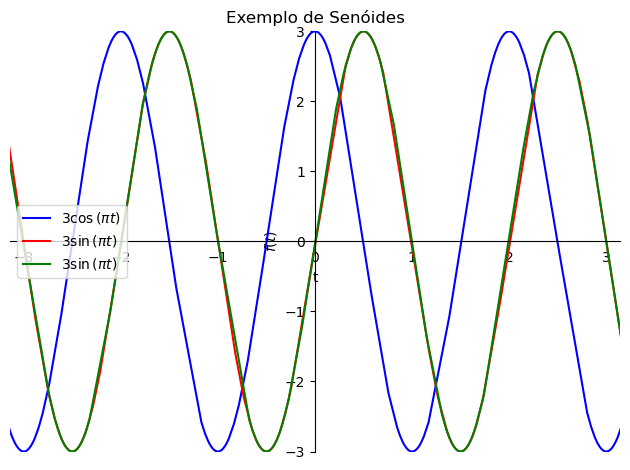

In [9]:
t = sym.Symbol('t')
f0 = sym.Symbol('f0')
C = sym.Symbol('C')

expr1 = C*cos(2*pi*f0*t)
expr2 = C*cos(2*pi*f0*t - pi/2)
expr3 = C*sin(2*pi*f0*t)

expr1 = expr1.subs([(f0,0.5),(C,3)])
expr2 = expr2.subs([(f0,0.5),(C,3)])
expr3 = expr3.subs([(f0,.5),(C,3)])
p = plot(expr1, expr2, expr3, xlim = [-pi, pi], ylim = [-3, 3], title='Exemplo de Senóides', xlabel='t', legend=True, show=False)

p[0].line_color = 'b'
p[1].line_color = 'r'
p[2].line_color = 'g'
#p.loc=(9)
p.show()

Na figura acima as duas senoides estão defasadas em $90^{\circ}$. 


É conveniente utilizar a variável $\omega_0$ (**frequência angular**) para expressar $2 \pi f_0$ :
$$
\omega_0=2 \pi f_0
$$
Com esta notação, a senóide pode ser expressa por
$$
x(t)=C \cos \left(\omega_0 t+\theta\right)
$$
na qual o período $T_0$ é dado por
$$
T_0=\frac{2 \pi}{\omega_0}
$$

Em discussões futuras, geralmente utilizaremos $\omega_0$ como frequência do sinal cos $\left(\omega_0 t+\theta\right)$, mas deve estar claro que a frequência dessa senóide é $f_0 \mathrm{~Hz}\left(f_0=\omega_0 / 2 \pi\right)$ e $\omega_0$ é na realidade a **frequência angular**.

A senóide genérica $C$ $\cos \left(\omega_0 t+\theta\right)$ pode ser rapidamente rascunhada deslocando o sinal $C \cos \omega_0 t$ da pela fase apropriada. Considere, por exemplo,
$$
x(t)=C \cos \left(\omega_0 t-60^{\circ}\right)
$$
Esse sinal pode ser obtido deslocando (atrasando) o sinal $C \cos \omega_0 t$ para a direita com uma fase (ângulo) de $60^{\circ}$. 





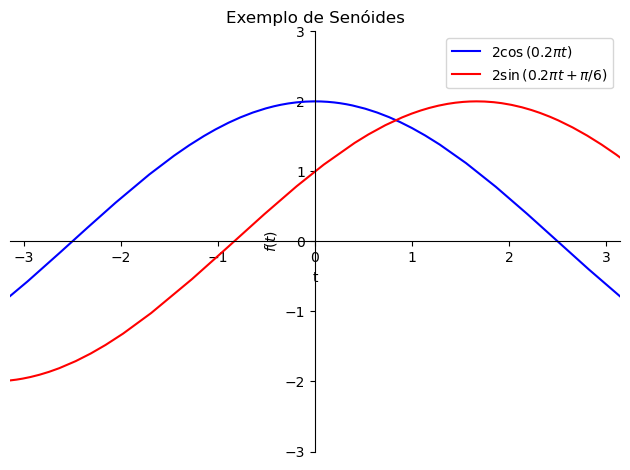

In [ ]:
expr1 = C*cos(2*pi*f0*t)
expr2 = C*cos(2*pi*f0*t - pi/3)
expr1 = expr1.subs([(f0,0.1),(C,2)])
expr2 = expr2.subs([(f0,0.1),(C,2)])
p = plot(expr1, expr2, xlim = [-pi, pi], ylim = [-3, 3], title='Exemplo de Senóides', xlabel='t', legend=True, show=False)
p[0].line_color = 'b'
p[1].line_color = 'r'
#p.loc=(9)
p.show()

Observe que se atrasamos $C \cos \omega_0 t$ por um quarto de ciclo (ângulo de $90^{\circ}$ ou $\pi / 2$ radianos), obtemos o sinal $C \operatorname{sen} \omega_0 t$. 

Isso verifica a bem conhecida identidade trigonométrica
$$
C \cos \left(\omega_0 t-\pi / 2\right)=C \operatorname{sen} \omega_0 t
$$


Alternativamente, se avançarmos $C \operatorname{sen} \omega_0 t$ por um quarto de ciclo, obtemos $C \cos \omega_0 t$, portanto,
$$
C \operatorname{sen}\left(\omega_0 t+\pi / 2\right)=C \cos \omega_0 t
$$
Essa observação implica que sen $\omega_0 t$ está atrasado de $\cos \omega_0 t$ por $90^{\circ}$ ( $\pi / 2$ radianos) ou $\cos \omega_0 t$ está adiantado de $\operatorname{sen} \omega_0 t$ por $90^{\circ}$.


#### 2.1 Adição de Senóides
Duas senóides com a mesma frequência mas diferentes ângulos de fase se somam para formar uma única senóide de mesma frequência. 

Esse fato é facilmente comprovado a partir da bem conhecida identidade trigonométrica
$$
\begin{aligned}
C \cos \left(\omega_0 t+\theta\right) & =C \cos \theta \cos \omega_0 t-C \operatorname{sen} \theta \operatorname{sen} \omega_0 t \\
& =a \cos \omega_0 t+b \operatorname{sen} \omega_0 t
\end{aligned}
$$
na qual
$$
a=C \cos \theta \quad \text { e } \quad b=-C \operatorname{sen} \theta
$$
Portanto,
$$
\begin{gathered}
C=\sqrt{a^2+b^2} \\
\theta=\tan ^{-1}\left(\frac{-b}{a}\right)
\end{gathered}
$$

In [ ]:
atan(sqrt(3)/3)

pi/6

Podemos, também, efetuar a operação inversa, expressando
$$
x(t)=C \cos \left(\omega_0 t+\theta\right)
$$
em termos de $\cos \omega_0 t$ e sen $\omega_0 t$ através da identidade trigonométrica
$$
C \cos \left(\omega_0 t+\theta\right)=C \cos \theta \cos \omega_0 t-C \operatorname{sen} \theta \operatorname{sen} \omega_0 t
$$

#### 2.2  Senóides em Termos de Exponenciais: A Fórmula de Euler

Senóides podem ser expressas em termos de exponenciais utilizando a fórmula de Euler
$$
\begin{aligned}
\cos \varphi & =\frac{1}{2}\left(e^{j \varphi}+e^{-j \varphi}\right) \\
\operatorname{sen} \varphi & =\frac{1}{2 j}\left(e^{j \varphi}-e^{-j \varphi}\right)
\end{aligned}
$$
A inversão dessas equações resulta em
$$
\begin{aligned}
e^{j \varphi} & =\cos \varphi+j \operatorname{sen} \varphi \\
e^{-j \varphi} & =\cos \varphi-j \operatorname{sen} \varphi
\end{aligned}
$$

**Exemplo 6:**

Nos casos a seguir, expresse $x(t)$ como uma única senoide:

(a) $x(t)=\cos \omega_0 t-\sqrt{3} \operatorname{sen} \omega_0 t$

(b) $x(t)=-3 \cos \omega_0 t+4 \operatorname{sen} \omega_0 t$

**Exemplo de computador 3**

Expresse $f(t)=-3 \cos \left(\omega_0 t\right)+4 \operatorname{sen}\left(\omega_0 t\right)$ como uma única senoide. 




### 3. Rascunhando Sinais

Nesta seção, iremos discutir o rascunho de alguns sinais úteis, começando com a exponencial

#### 3.1 Exponenciais Monotônicas

O sinal $e^{-a t}$ decai monotonicamente, e o sinal $e^{a t}$ cresce monotonicamente com $t$ (assumindo $a>0$ ), como mostrado abaixo

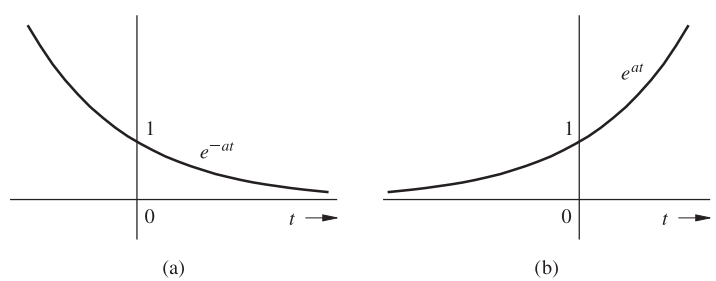


Por questões de simplicidade, iremos considerar uma exponencial $e^{-a t}$ começando de $t=0$, como mostrado na figura (a) abaixo.
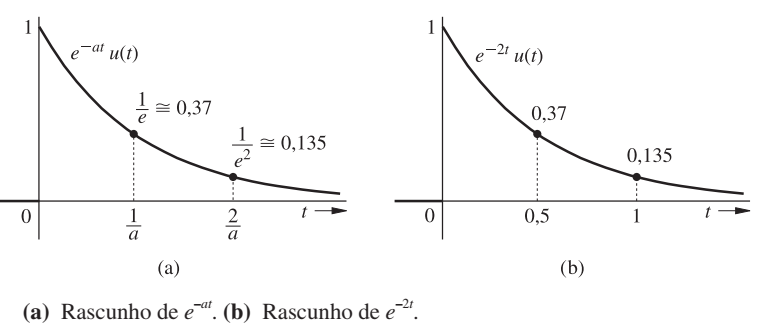

O sinal $e^{-a t}$ possui valor unitário para $t=0$. Para $t=1 / a$, o valor cai para 1/e (aproximadamente $37 \%$ de seu valor inicial), como mostrado na figura (a) acima. 

Este intervalo de tempo no qual a exponencial reduz por um fator $e$ (isto é, cai para aproximadamente 37\% de seu valor) é chamado de **constante de tempo da exponencial**. Portanto, a constante de tempo de $e^{-a t}$ é $1 / a$. Observe que a exponencial é reduzida para 37\% de seu valor inicial para qualquer intervalo de tempo de duração 1/a. Este fato pode ser mostrado considerando-se qualquer conjunto de instantes $t_1$ e $t_2$ separados por uma constante de tempo, tal que
$$
t_2-t_1=\frac{1}{a}
$$
Agora, a razão de $e^{-a t_2}$ para $e^{-a t_1}$ é dada por
$$
\frac{e^{-a t_{2}}}{e^{-a t_{1}}}=e^{-a\left(t_2-t_1\right)}=\frac{1}{e} \approx 0,37
$$
Nós podemos utilizar este fato para desenhar rapidamente a exponencial. Por exemplo, considere
$$
x(t)=e^{-2 t}
$$

A constante de tempo deste caso é 0,5 . O valor de $x(t)$ para $t=1$. Para $t=0,5$ (uma constante de tempo), o valor de $x(t)$ é 1/e (aproximadamente 0,37). O valor de $x(t)$ continua caindo por um fator de 1/e (37\%) a cada intervalo de tempo de meio segundo (uma constante de tempo). Portanto, $x(t)$ para $t=1$ é (1/e) ${ }^2$. Continuando desta forma, observamos que $x(t)=(1 / e)^3$ para $t=1,5$ e assim por diante. O conhecimento dos valores de $x(t)$ para $t=0 ; 0,5 ; 1$ e 1,5 nos permite traçar o sinal desejado como mostrado na figura acima.

Para a exponencial monotonicamente crescente $e^{a t}$, a forma de onda aumenta por um fator $e$ a cada intervalo de $1 / a$ segundos.



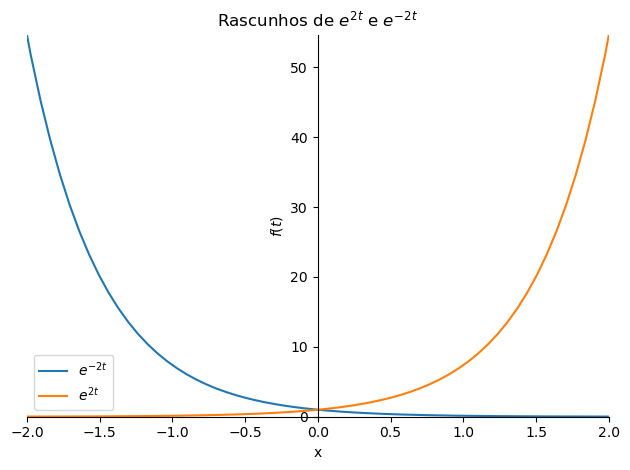

In [ ]:
t = sym.Symbol('t')
expr1 = exp(-2*t)
expr2 = exp(2*t)

plot(expr1, expr2, xlim = [-2, 2], ylim = [0,exp(4)], adaptive=False, 
     title='Rascunhos de $e^{2t}$ e $e^{-2t}$', xlabel='x', legend = 'True')
#markers=[{'args': [2,2, 'ro']}]

#### 3.2 Senóides Variando Exponencialmente
Agora, discutiremos como traçar uma senóide com variação exponencial de amplitude
$$
x(t)=A e^{-a t} \cos \left(\omega_0 t+\theta\right)
$$
Vamos considerar um exemplo específico:
$$
x(t)=4 e^{-2 t} \cos (6 t-60)
$$
Devemos traçar $4 e^{-2 t}$ e $\cos \left(6 t-60^{\circ}\right)$ separadamente e, então, multiplicá-los. Abaixo, apresentamos o gráfico obtido com o sympy-plot.

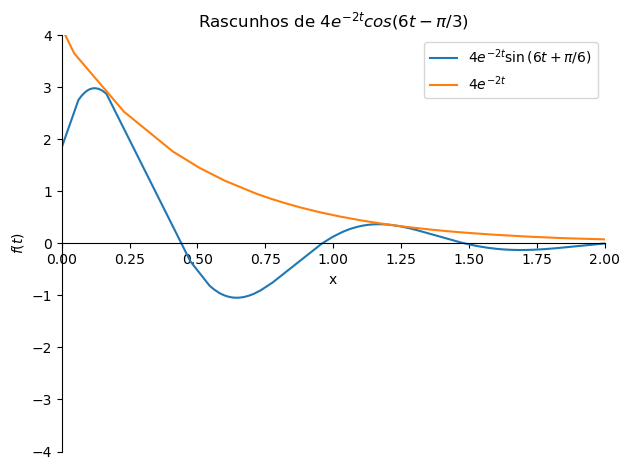

In [ ]:
t = sym.Symbol('t')
expr3 = 4*exp(-2*t)*cos(6*t - pi/3)


plot(expr3,4*exp(-2*t), xlim = [0, 2], ylim = [-4,4], adaptive=True,
     title='Rascunhos de $4e^{-2t}cos(6t - \pi/3)$', xlabel='x', legend = 'True')
#markers=[{'args': [2,2, 'ro']}]

### 4.  Regra de Cramer

A regra de Cramer é uma forma muito conveniente para resolver equações lineares simultâneas. Considere um conjunto de $n$ equações lineares simultâneas com $n$ incógnitas $x_1, x_2, \ldots, x_n$ :
$$
\begin{gathered}
a_{11} x_1+a_{12} x_2+\cdots+a_{1 n} x_n=y_1 \\
a_{21} x_1+a_{22} x_2+\cdots+a_{2 n} x_n=y_2 \\
\vdots \\
a_{n 1} x_1+a_{n 2} x_2+\cdots+a_{n n} x_n=y_n
\end{gathered}
$$
Estas equações podem ser colocadas na forma matricial como
$$
\left[\begin{array}{cccc}
a_{11} & a_{12} & \cdots & a_{1 n} \\
a_{21} & a_{22} & \cdots & a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
a_{n 1} & a_{n 2} & \cdots & a_{n n}
\end{array}\right]\left[\begin{array}{c}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{array}\right]=\left[\begin{array}{c}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{array}\right]
$$

Chamamos a matriz do lado esquerdo, formada pelos elementos $a_{i j}$ de $\mathbf{A}$. 

O determinante de $\mathbf{A}$ é representado por $|\mathbf{A}|$. 

Se o determinante $|\mathbf{A}|$ for não nulo, o conjunto de equações acima possui uma única solução dada pela **fórmula de Cramer**
$$
x_k=\frac{\left|\mathbf{D}_k\right|}{|\mathbf{A}|} \quad k=1,2, \ldots, n
$$
onde $\left|\mathbf{D}_k\right|$ é obtido substituindo a $k$-ésima coluna de $|\mathbf{A}|$ pela coluna do lado direito da equação matricial acima (com elementos $\left.y_1, y_2, \ldots, y_n\right)$.

Demonstraremos esta regra através de um exemplo.


**Exemplo 7** 

Utilize a Regra de Cramer para resolver as seguintes equações lineares simultâneas com três incógnitas.
$$
\begin{array}{r}
2 x_1+x_2+x_3=3 \\
x_1+3 x_2-x_3=7 \\
x_1+x_2+x_3=1
\end{array}
$$
A forma matricial dessas equações pode ser escrita por
$$
\left[\begin{array}{ccc}
2 & 1 & 1 \\
1 & 3 & -1 \\
1 & 1 & 1
\end{array}\right]\left[\begin{array}{l}
x_1 \\
x_2 \\
x_3
\end{array}\right]=\left[\begin{array}{l}
3 \\
7 \\
1
\end{array}\right]
$$
onde

$$
|\mathbf{A}|=\left|\begin{array}{ccc}
2 & 1 & 1 \\
1 & 3 & -1 \\
1 & 1 & 1
\end{array}\right|=4
$$

Como $|\mathbf{A}|=4 \neq 0$, uma única solução existe para $x_1, x_2$ e $x_3$. Esta solução é dada pela regra de Cramer, mostrada a seguir:
$$
\begin{aligned}
& x_1=\frac{1}{|\mathbf{A}|}\left|\begin{array}{ccc}
3 & 1 & 1 \\
7 & 3 & -1 \\
1 & 1 & 1
\end{array}\right|=\frac{8}{4}=2 \\
& x_2=\frac{1}{|\mathbf{A}|}\left|\begin{array}{ccc}
2 & 3 & 1 \\
1 & 7 & -1 \\
1 & 1 & 1
\end{array}\right|=\frac{4}{4}=1 \\
& x_3=\frac{1}{|\mathbf{A}|}\left|\begin{array}{lll}
2 & 1 & 3 \\
1 & 3 & 7 \\
1 & 1 & 1
\end{array}\right|=\frac{-8}{4}=-2
\end{aligned}
$$


**Observação** A Regra de Cramer tem pouca aplicação prática para $n \geq 5$. De fato, temos a seguinte comparação com o método de Eliminação Gaussiana, quanto a complexidade e o tempo de computação para um sistema de 30 equações (considerando um supercomputador BlueGene ∼180 TFlops)

\begin{array}{l|c|c}
\text { método } & \text { Complexidade } & \text { tempo para } n=30\left(^*\right) \\
\hline \text { Regra de Cramer } & \sim(n+1) ! & 1.4 \times 10^{12} \text { anos } \\
\text { Eliminação gaussiana } & \sim n^3 / 3 & 0.05 \times 10^{-9} \mathrm{~s}
\end{array}

In [11]:
''' Cramer Rule Matrix Systems Calculator and Laplace Theorem
Cramer's Rule | Xi = det(Ai) / det(A)
Laplace       | Sum cof(A)i*j * A(i*j)
Cofactor      | (-1)^i+j * det(A)i*j'''

# Laplace algorithm
def laplace(matrix, val=1):
    # Set the matrix length
    n = len(matrix)

    # Return Det if Matrix length is 1
    if n == 1:
        return val * matrix[0][0]
    else:
        sign = -1
        det = 0
        for i in range(n):
            mtx = []
            for j in range(1, n):
                buff = []
                for k in range(n):
                    if k != i:
                        buff.append(matrix[j][k])
                mtx.append(buff)
            sign *= -1
            det += val * laplace(mtx, sign * matrix[0][i])
        return det

# Cramer algorithm
def cramer(matrix, results, order):
    # Calc and Show Main Matrix Determinant
    main_det = laplace(matrix)
    print(f'\nMain matrix determinant: {main_det}')

    # Build New Matrix with Substitutions
    if main_det != 0:
        resolution = []
        for r in range(order):
            matrix_sub = []
            for i in range(order):
                matrix_sub.append([])
                for j in range(order):
                    if j == r:
                        matrix_sub[i].append(results[i])
                    else:
                        matrix_sub[i].append(matrix[i][j])

            # Show Actual Matrix with Substitution
            print(f'\nMatrix with replacement at COLUMN {r + 1}:')
            for line in matrix_sub:
                for val in line:
                    print(f'{val:^8}', end=' ')
                print()

            # Calc Determinant with Substitution
            sub_det = laplace(matrix_sub)
            print(f'Determinant of this matrix: {sub_det}')

            # Calc and Save Final Resolution
            resolution.append(sub_det / main_det)

    # Return Resolution to Display in Main
        return resolution

    # Display Resolution if Main Det is 0
    else:
        return 0

# Main function
def main():
    # Read Matrix Range
    order = int(input('Enter the Matrix Order: '))

    # Read Matrix Numbers
    print(f'Enter the Matrix {order}x{order} formatted with SPACES (for columns) and ENTERS (for lines):')
    matrix = [list(map(float, input().split())) for i in range(order)]

    # Read Matrix Results
    results = list(map(float, input('Enter the respective results for LINES separated by SPACES: ').split()))

    # Show Mounted Matrix
    print('\nCheck if your system is mounted correctly:\n')
    for l, line in enumerate(matrix):
        for val in line:
            print(f'{val:^8}', end=' ')
        print(f'= {results[l]:^8}', end='\n')

    # Define if Has Correct Data
    reset = input('\nEnter (Y) for YES or (N) for NO. (YES is default): ').lower()
    if reset == 'n':
        print(), main()
    else:
        # Show Final Results
        resolution = cramer(matrix, results, order)
        if resolution != 0:
            print('\nSolution set:')
            for r in range(order):
                print(f'A{r + 1} = {resolution[r]}')
        else:
            print('\nImpossible to finish algorithm.\nThe determinant of the main matrix is EQUAL to 0.')


main()

Enter the Matrix 3x3 formatted with SPACES (for columns) and ENTERS (for lines):

Check if your system is mounted correctly:

  2.0      1.0      1.0    =   3.0   
  1.0      3.0      -1.0   =   7.0   
  1.0      1.0      1.0    =   1.0   

Main matrix determinant: 4.0

Matrix with replacement at COLUMN 1:
  3.0      1.0      1.0    
  7.0      3.0      -1.0   
  1.0      1.0      1.0    
Determinant of this matrix: 8.0

Matrix with replacement at COLUMN 2:
  2.0      3.0      1.0    
  1.0      7.0      -1.0   
  1.0      1.0      1.0    
Determinant of this matrix: 4.0

Matrix with replacement at COLUMN 3:
  2.0      1.0      3.0    
  1.0      3.0      7.0    
  1.0      1.0      1.0    
Determinant of this matrix: -8.0

Solution set:
A1 = 2.0
A2 = 1.0
A3 = -2.0


### 5 Expansão em Frações Parciais

Durante a análise de sistemas lineares invariantes no tempo encontramos funções que são razões de dois polinômios de uma certa variável, digamos $x$. 

Tais funções são chamadas de funções racionais. Uma função racional $F(x)$ pode ser descrita por
$$
\begin{aligned}
F(x) & =\frac{b_m x^m+b_{m-1} x^{m-1}+\cdots+b_1 x+b_0}{x^n+a_{n-1} x^{n-1}+\cdots+a_1 x+a_0} \\
& =\frac{P(x)}{Q(x)}
\end{aligned}
$$
A função $F(x)$ é imprópria se $m \geq n$ e própria se $m<n$. Uma função imprópria pode ser sempre separada na soma de um polinômio em $x$ e uma função própria. Considere, por exemplo, a função
$$
F(x)=\frac{2 x^3+9 x^2+11 x+2}{x^2+4 x+3}
$$
Como essa é uma função imprópria, dividimos o numerador pelo denominador até que o resto possua um grau menor do que o denominador.

Portanto, $F(x)$ pode ser escrita por
$$
F(x)=\frac{2 x^3+9 x^2+11 x+2}{x^2+4 x+3}=\underbrace{2 x+1}_{\text {polinômio em } x}+\underbrace{\frac{x-1}{x^2+4 x+3}}_{\text {função própria }}
$$
Uma função própria pode ser expandida, posteriormente, em frações parciais. O restante desta seção irá discutir as diversas formas de se fazer isto.

Em python, basta chamar a função **apart()** como ilustrado abaixo.

In [ ]:
x = sym.Symbol('x')
expr1 = 2*x**3 + 9*x**2 + 11*x + 2
expr2 = x**2 + 4*x + 3
F = expr1/expr2
apart(F)

2*x + 1 + 2/(x + 3) - 1/(x + 1)

#### 5.1 Método de Eliminação de Frações
Uma função racional pode ser escrita como a soma de frações parciais apropriadas com coeficientes desconhecidos, os quais são determinados pela eliminação de frações e igualando os coeficientes de potência similar dos dois lados. Este procedimento é demonstrado pelo exemplo a seguir.

Apesar deste método poder ser aplicado diretamente em todas as situações, ele não é necessariamente o mais eficiente. Discutiremos outros métodos que podem reduzir consideravelmente o trabalho numérico.

**Exemplo 8.**

Expanda a seguinte função racional $F(x)$ em frações parciais:
$$
F(x)=\frac{x^3+3 x^2+4 x+6}{(x+1)(x+2)(x+3)^2}
$$
Esta função pode ser escrita como a soma de frações parciais com denominadores $(x+1),(x+2)$, $(x+3)$ e $(x+3)^2$, como mostrado a seguir:
$$
F(x)=\frac{x^3+3 x^2+4 x+6}{(x+1)(x+2)(x+3)^2}=\frac{k_1}{x+1}+\frac{k_2}{x+2}+\frac{k_3}{x+3}+\frac{k_4}{(x+3)^2}
$$
Para determinar as incógnitas $k_1, k_2, k_3$ e $k_4$, eliminamos as frações multiplicando os dois lados por $(x+1)(x+2)(x+3)^2$, obtendo

$$
\begin{aligned}
x^3+3 x^2+4 x+6 & = k_1\left(x^3+8 x^2+21 x+18\right)+k_2\left(x^3+7 x^2+15 x+9\right) \\
& +k_3\left(x^3+6 x^2+11 x+6\right)+k_4\left(x^2+3 x+2\right) \\
& =  x^3\left(k_1+k_2+k_3\right)+x^2\left(8 k_1+7 k_2+6 k_3+k_4\right) \\
& +x\left(21 k_1+15 k_2+11 k_3+3 k_4\right)+\left(18 k_1+9 k_2+6 k_3+2 k_4\right)
\end{aligned}
$$

Igualando os coeficientes de mesma potência dos dois lados teremos
$$
\begin{array}{r}
k_1+k_2+k_3=1 \\
8 k_1+7 k_2+6 k_3+k_4=3 \\
21 k_1+15 k_2+11 k_3+3 k_4=4 \\
18 k_1+9 k_2+6 k_3+2 k_4=6
\end{array}
$$
A solução dessas quatro equações simultâneas resulta em
$$
k_1=1, \quad k_2=-2, \quad k_3=2, \quad k_4=-3
$$
Logo,
$$
F(x)=\frac{1}{x+1}-\frac{2}{x+2}+\frac{2}{x+3}-\frac{3}{(x+3)^2}
$$

In [ ]:
x = sym.Symbol('x')
expr1 = x**3 + 3*x**2 + 4*x + 6
expr2 = (x+1)*(x+2)*(x+3)**2
F = expr1/expr2
apart(F)

2/(x + 3) - 3/(x + 3)**2 - 2/(x + 2) + 1/(x + 1)

#### 5.1 Método de Heaviside
**Fatores distintos de $\mathrm{Q}(\mathrm{x})$**

Iremos, inicialmente, considerar a expansão em frações parciais de $F(x)=P(x) / Q(x)$, na qual todos os fatores de $Q(x)$ são distintos (não repetidos). Considere a seguinte função própria
$$
\begin{aligned}
F(x) & =\frac{b_m x^m+b_{m-1} x^{m-1}+\cdots+b_1 x+b_0}{x^n+a_{n-1} x^{n-1}+\cdots+a_1 x+a_0} \quad m<n \\
& =\frac{P(x)}{\left(x-\lambda_1\right)\left(x-\lambda_2\right) \cdots\left(x-\lambda_n\right)}
\end{aligned}
$$
Podemos mostrar que $F(x)$ pode ser escrita como a soma das frações parciais
$$
F(x)=\frac{k_1}{x-\lambda_1}+\frac{k_2}{x-\lambda_2}+\cdots+\frac{k_n}{x-\lambda_n}
$$
Para determinar o coeficiente $k_1$, multiplicamos os dois lados da equação acima por $x-\lambda_1$ e, então, fazemos $x=$ $\lambda_1$, resultando em

$$
\left.\left(x-\lambda_1\right) F(x)\right|_{x=\lambda_1}=k_1+\frac{k_2\left(x-\lambda_1\right)}{\left(x-\lambda_2\right)}+\frac{k_3\left(x-\lambda_1\right)}{\left(x-\lambda_3\right)}+\cdots+\left.\frac{k_n\left(x-\lambda_1\right)}{\left(x-\lambda_n\right)}\right|_{x=\lambda_1}
$$
No lado direito, todo os termos exceto $k_1$ desaparecem. Portanto,
$$
k_1=\left.\left(x-\lambda_1\right) F(x)\right|_{x=\lambda_1}
$$
Similarmente, podemos mostrar que
$$
k_r=\left.\left(x-\lambda_r\right) F(x)\right|_{x=\lambda_r} \quad r=1,2, \ldots, n
$$
Este procedimento também recebe o nome de **método dos resíduos**.

**Exemplo 9**

Expanda a seguinte função racional $F(x)$ em frações parciais:
$$
F(x)=\frac{2 x^2+9 x-11}{(x+1)(x-2)(x+3)}=\frac{k_1}{x+1}+\frac{k_2}{x-2}+\frac{k_3}{x+3}
$$
Para determinar $k_1$, fazemos $x=-1$ em $(x+1) F(x)$. Note que $(x+1) F(x)$ é obtido de $F(x)$ omitindo o termo $(x+1)$ de seu denominador. Portanto, para calcular $k_1$ correspondente ao fator $(x+1)$, escondemos o termo $(x+1)$ do denominador de $F(x)$ e, então, substituímos $x=-1$ na expressão restante. 

Os passos para trabalhar a função
$$
F(x)=\frac{2 x^2+9 x-11}{(x+1)(x-2)(x+3)}
$$
estão mostrados a seguir.

- Passo 1. Esconda o fator $(x+1)$ de $F(x)$ :
$$
\frac{2 x^2+9 x-11}{(x-2)(x+3)}
$$

- Passo 2. Substitua $x=-1$ na expressão restante para obter $k_1$ :
$$
k_1=\frac{2-9-11}{(-1-2)(-1+3)}=\frac{-18}{-6}=3
$$
De forma equivalente, para determinar $k_2$ escondemos o fator $(x-2)$ em $F(x)$ e fazemos $x=2$ na função restante, como mostrado a seguir:
$$
k_2=\left.\frac{2 x^2+9 x-11}{(x+1)(x+3)}\right|_{x=2}=\frac{8+18-11}{(2+1)(2+3)}=\frac{15}{15}=1
$$
e
$$
k_3=\left.\frac{2 x^2+9 x-11}{(x+1)(x-2)}\right|_{x=-3}=\frac{18-27-11}{(-3+1)(-3-2)}=\frac{-20}{10}=-2
$$
Portanto,

$$
F(x)=\frac{2 x^2+9 x-11}{(x+1)(x-2)(x+3)}=\frac{3}{x+1}+\frac{1}{x-2}-\frac{2}{x+3}
$$

**Fatores Complexos de $Q(X)$**

O procedimento recém apresentado funciona independentemente se os fatores de $Q(x)$ são reais ou complexos. Considere, por exemplo,
$$
\begin{aligned}
F(x) & =\frac{4 x^2+2 x+18}{(x+1)\left(x^2+4 x+13\right)} \\
& =\frac{4 x^2+2 x+18}{(x+1)(x+2-j 3)(x+2+j 3)} \\
& =\frac{k_1}{x+1}+\frac{k_2}{x+2-j 3}+\frac{k_3}{x+2+j 3}
\end{aligned}
$$
onde
$$
k_1=\left[\frac{4 x^2+2 x+18}{\left(x^2+4 x+13\right)}\right]_{x=-1}=2
$$

Similarmente,
$$
\begin{aligned}
& k_2=\left[\frac{4 x^2+2 x+18}{(x+1)(x+2-j 3)(x+2+j 3)}\right]_{x=-2+j 3}=1+j 2=\sqrt{5} e^{j 63,43^{\circ}} \\
& k_3=\left[\frac{4 x^2+2 x+18}{(x+1)(x+2-j 3)(x+2+j 3)}\right]_{x=-2-j 3}=1-j 2=\sqrt{5} e^{-j 63,43^{\circ}}
\end{aligned}
$$
Portanto,
$$
F(x)=\frac{2}{x+1}+\frac{\sqrt{5} e^{j 63,43^{\circ}}}{x+2-j 3}+\frac{\sqrt{5} e^{-j 63,43^{\circ}}}{x+2+j 3}
$$
Os coeficiente $k_2$ e $k_3$ correspondentes aos fatores complexos conjugados também são conjugados. Este fato geralmente é verdadeiro quando os coeficientes da função racional são reais. Em tais casos, precisamos determinar apenas um dos coeficientes.

In [ ]:
x = sym.Symbol('x')
expr1 = 4*x**2 + 2*x + 18
expr2 = (x+1)*(x**2+4*x+13)
F = expr1/expr2
apart(F, extension=I)# para o caso de raízes complexas

(1 - 2*I)/(x + 2 + 3*I) + (1 + 2*I)/(x + 2 - 3*I) + 2/(x + 1)

**Fatores Quadráticos**

Geralmente precisamos combinar dois termos resultantes de fatores complexos conjugados em um único fator quadrático. Por exemplo, $F(x)$ acima pode ser escrita por
$$
F(x)=\frac{4 x^2+2 x+18}{(x+1)\left(x^2+4 x+13\right)}=\frac{k_1}{x+1}+\frac{c_1 x+c_2}{x^2+4 x+13}
$$
O coeficiente $k_1$ é determinado pelo método de Heaviside, sendo igual a 2. Portanto,
$$
\frac{4 x^2+2 x+18}{(x+1)\left(x^2+4 x+13\right)}=\frac{2}{x+1}+\frac{c_1 x+c_2}{x^2+4 x+13}
$$
Os valores de $c_1$ e $c_2$ são determinados eliminando as frações e igualando os coeficientes de mesma potência de $x$ dos dois lados da equação resultante. 

A eliminação das frações nos dois lados da última equação resulta em
$$
\begin{aligned}
4 x^2+2 x+18 & =2\left(x^2+4 x+13\right)+\left(c_1 x+c_2\right)(x+1) \\
& =\left(2+c_1\right) x^2+\left(8+c_1+c_2\right) x+\left(26+c_2\right)
\end{aligned}
$$
Igualando os termos de mesma potência temos $c_1=2, c_2=-8$, e

$$
\frac{4 x^2+2 x+18}{(x+1)\left(x^2+4 x+13\right)}=\frac{2}{x+1}+\frac{2 x-8}{x^2+4 x+13}
$$

**Atalhos** 

Os valores de $c_1$ e $c_2$ também podem ser determinados utilizando atalhos. 

Após determinar $k_1=$ 2 pelo método de Heaviside, fazemos $x=0$ nos dois lados da equação para eliminar $c_1$, resultando em
$$
\frac{18}{13}=2+\frac{c_2}{13}
$$
Portanto,
$$
c_2=-8
$$
Para determinar $c_1$, multiplicamos os dois lados da equação por $x$ e, então, fazemos $x \rightarrow \infty$. Lembre-se de que quando $x \rightarrow \infty$ apenas os termos de potência mais alta são significativos. Portanto,
$$
4=2+c_1
$$
e
$$
c_1=2
$$

No procedimento discutido, fizemos $x=0$ para determinar $c_2$ e, então, multiplicamos os dois lados por $x$ e fizemos $x \rightarrow \infty$ para determinar $c_1$. Entretanto, esses valores não são sagrados $(x=0$ ou $x=\infty)$. 

Utilizamo-nos porque eles reduziram a quantidade de cálculo envolvida. Poderíamos utilizar, também, outros valores convenientes para $x$, tal como $x=1$. Considere o caso
$$
\begin{aligned}
F(x) & =\frac{2 x^2+4 x+5}{x\left(x^2+2 x+5\right)} \\
& =\frac{k}{x}+\frac{c_1 x+c_2}{x^2+2 x+5}
\end{aligned}
$$
Determinamos $k=1$ normalmente pelo método de Heaviside. Como resultado,
$$
\frac{2 x^2+4 x+5}{x\left(x^2+2 x+5\right)}=\frac{1}{x}+\frac{c_1 x+c_2}{x^2+2 x+5}
$$

Para determinar $c_1$ e $c_2$, se tentarmos fazer $x=0$ iremos obter $\infty$ nos dois lados. Portanto, iremos escolher $x=1$, resultando em
$$
\frac{11}{8}=1+\frac{c_1+c_2}{8}
$$
ou
$$
c_1+c_2=3
$$
Podemos, agora, escolher algum outro valor para $x$, tal como $x=2$ para obter mais uma relação a ser utilizada para determinar $c_1$ e $c_2$. Neste caso, entretanto, um método simples é multiplicar os dois lados da equação por $x$ e, então, fazermos $x \rightarrow \infty$, resultando em
$$
2=1+c_1
$$
de tal forma que
$$
c_1=1 \quad \text { e } \quad c_2=2
$$
Portanto,
$$
F(x)=\frac{1}{x}+\frac{x+2}{x^2+2 x+5}
$$

#### 5.3 Fatores Repetidos de $Q(x)$

Se uma função $F(x)$ possui fatores repetidos em seu denominador, ela terá a forma
$$
F(x)=\frac{P(x)}{(x-\lambda)^r\left(x-\alpha_1\right)\left(x-\alpha_2\right) \cdots\left(x-\alpha_j\right)}
$$
Sua expansão em frações parciais é dada por
$$
\begin{aligned}
F(x)= & \frac{a_0}{(x-\lambda)^r}+\frac{a_1}{(x-\lambda)^{r-1}}+\cdots+\frac{a_{r-1}}{(x-\lambda)} \\
& +\frac{k_1}{x-\alpha_1}+\frac{k_2}{x-\alpha_2}+\cdots+\frac{k_j}{x-\alpha_j}
\end{aligned}
$$
Os coeficientes $k_1, k_2, \ldots, k_j$ correspondentes aos fatores não repetidos nesta equação são determinados pelo método Heaviside, como mostrado anteriormente. Para determinar os coeficientes $a_0, a_1, a_2, \ldots, a_{r-1}$, multiplicamos os dois lados da última equação por $(x-\lambda)^r$, resultando em

$$
\begin{aligned}
(x-\lambda)^r F(x)= & a_0+a_1(x-\lambda)+a_2(x-\lambda)^2+\cdots+a_{r-1}(x-\lambda)^{r-1} \\
& +k_1 \frac{(x-\lambda)^r}{x-\alpha_1}+k_2 \frac{(x-\lambda)^r}{x-\alpha_2}+\cdots+k_n \frac{(x-\lambda)^r}{x-\alpha_n}
\end{aligned}
$$
Se fizermos $x=\lambda$ nos dois lados da equação acima iremos obter
$$
\left.(x-\lambda)^r F(x)\right|_{x=\lambda}=a_0
$$

Portanto, $a_0$ é obtido escondendo o fator $(x-\lambda)^r \mathrm{em} F(x)$ e fazendo $x=\lambda$ na expressão restante (método de Heaviside). 

Se fizermos a derivada (com relação a $x$ ) dos dois lados da equação, o lado direito será $a_1+$ termos contendo o fator $(x-\lambda)$ em seus numeradores. Fazendo $x=\lambda$ nos dois lados desta equação, iremos obter
$$
\left.\frac{d}{d x}\left[(x-\lambda)^r F(x)\right]\right|_{x=\lambda}=a_1
$$
Portanto, $a_1$ é obtido ocultando o fator $(x-\lambda)^r$ em $F(x)$, determinando a derivada da expressão restante e, então, fazendo $x=\lambda$. Continuando desta maneira, iremos obter
$$
a_j=\left.\frac{1}{j !} \frac{d^j}{d x^j}\left[(x-\lambda)^r F(x)\right]\right|_{x=\lambda}
$$

Observe que $(x-\lambda)^r F(x)$ é obtido de $F(x)$ omitindo o fator $(x-\lambda)^r$ de seu denominador. Portanto, o coeficiente $a_j$ é obtido ocultando o fator $(x-\lambda)^r$ de $F(x)$, determinando a $j$-ésima derivada da expressão restante e, então, fazendo $x=\lambda$ (enquanto dividimos por $j!$).

**Exemplo 10**
Expanda $F(x)$ em frações parciais se
$$
F(x)=\frac{4 x^3+16 x^2+23 x+13}{(x+1)^3(x+2)}
$$


As frações parciais são
$$
F(x)=\frac{a_0}{(x+1)^3}+\frac{a_1}{(x+1)^2}+\frac{a_2}{x+1}+\frac{k}{x+2}
$$
O coeficiente $k$ é obtido ocultando o fator $(x+2)$ de $F(x)$ e, então, substituindo $x=-2$ na expressão restante:
$$
k=\left.\frac{4 x^3+16 x^2+23 x+13}{(x+1)^3}\right|_{x=-2}=1
$$
Para determinar $a_0$, ocultamos o fator $(x+1)^3$ em $F(x)$ e fazemos $x=-1$ na expressão restante:
$$
a_0=\left.\frac{4 x^3+16 x^2+23 x+13}{(x+2)}\right|_{x=-1}=2
$$

Para determinar $a_1$, ocultamos o fator $(x+1)^3$ em $F(x)$, determinamos a derivada da expressão restante e, então, fazemos $x=-1$ :
$$
a_1=\left.\frac{d}{d x}\left[\frac{4 x^3+16 x^2+23 x+13}{(x+2)}\right]\right|_{x=-1}=1
$$
Similarmente,
$$
a_2=\left.\frac{1}{2 !} \frac{d^2}{d x^2}\left[\frac{4 x^3+16 x^2+23 x+13}{(x+2)}\right]\right|_{x=-1}=3
$$
Portanto,
$$
F(x)=\frac{2}{(x+1)^3}+\frac{1}{(x+1)^2}+\frac{3}{x+1}+\frac{1}{x+2}
$$

#### 5.4 Mistura dos Métodos de Heaviside e Eliminação de Frações

Para várias raízes, especialmente para ordens mais altas, o método de expansão de Heaviside, o qual necessita de repetidas diferenciações, pode ser trabalhoso. Para uma função que contém diversas raízes repetidas e não repetidas, um método híbrido dos dois procedimentos é melhor. Os coeficientes simples são determinados pelo método de Heaviside e os coeficientes restantes são determinados pelo método de eliminação de frações ou atalhos, incorporando, portanto, o melhor dos dois métodos. Demonstraremos este procedimento resolvendo o Exemplo 10 novamente usando esta metodologia.



No Exemplo 10, os coeficientes $k$ e $a_0$ são relativamente simples de serem determinados pelo método de expansão de Heaviside. Estes valores foram determinados como $k_1=1$ e $a_0=2$. Portanto,
$$
\frac{4 x^3+16 x^2+23 x+13}{(x+1)^3(x+2)}=\frac{2}{(x+1)^3}+\frac{a_1}{(x+1)^2}+\frac{a_2}{x+1}+\frac{1}{x+2}
$$
Agora, multiplicaremos os dois lados desta equação por $(x+1)^3(x+2)$ para eliminar as frações. Essa multiplicação resulta em
$$
\begin{aligned}
4 x^3 & +16 x^2+23 x+13 \\
& =2(x+2)+a_1(x+1)(x+2)+a_2(x+1)^2(x+2)+(x+1)^3 \\
& =\left(1+a_2\right) x^3+\left(a_1+4 a_2+3\right) x^2+\left(5+3 a_1+5 a_2\right) x+\left(4+2 a_1+2 a_2+1\right)
\end{aligned}
$$
Igualando os coeficientes de potência dois e três de $x$ dos dois lados obtemos
$$
\left.\begin{array}{r}
1+a_2=4 \\
a_1+4 a_2+3=16
\end{array}\right\} \Longrightarrow \begin{aligned}
& a_1=1 \\
& a_2=3
\end{aligned}
$$

Podemos parar aqui se quisermos, pois os dois coeficientes, $a_1$ e $a_2$ já foram determinados. Entretanto, igualando os coeficientes das duas potências restantes de $x$ resulta em uma conveniente verificação da resposta. Igualando os coeficientes dos termos de $x^1$ e $x^0$, obtemos
$$
\begin{aligned}
& 23=5+3 a_1+5 a_2 \\
& 13=4+2 a_1+2 a_2+1
\end{aligned}
$$
Essas equações são satisfeitas pelos valores $a_1=1$ e $a_2=3$, determinados anteriormente, funcionando como uma verificação de nossas respostas. Portanto,
$$
F(x)=\frac{2}{(x+1)^3}+\frac{1}{(x+1)^2}+\frac{3}{x+1}+\frac{1}{x+2}
$$
a qual é a mesma resposta obtida anteriormente.


**Uma Mistura do Método de Heaviside e de Atalhos**

No Exemplo 10, após determinarmos os coeficientes $a_0=2$ e $ k=1$ pelo método de Heaviside. Dessa forma temos
$$
\frac{4 x^3+16 x^2+23 x+13}{(x+1)^3(x+2)}=\frac{2}{(x+1)^3}+\frac{a_1}{(x+1)^2}+\frac{a_2}{x+1}+\frac{1}{x+2}
$$
Existem apenas dois coeficientes a serem determinados, $a_1$ e $a_2$. Se multiplicarmos os dois lados desta equação por $x$ e fizermos $x \rightarrow \infty$, poderemos eliminar $a_1$, resultando em
$$
4=a_2+1 \quad \Longrightarrow \quad a_2=3
$$
Portanto,
$$
\frac{4 x^3+16 x^2+23 x+13}{(x+1)^3(x+2)}=\frac{2}{(x+1)^3}+\frac{a_1}{(x+1)^2}+\frac{3}{x+1}+\frac{1}{x+2}
$$
Existe, agora, apenas uma incógnita $a_1$, a qual pode ser facilmente determinada se fizermos $x$ igual a qualquer valor conveniente, digamos $x=0$.


$$
\frac{13}{2}=2+a_1+3+\frac{1}{2} \Longrightarrow a_1=1
$$
a qual é a mesma resposta encontrada anteriormente.
Existem outros possíveis atalhos. Por exemplo, podemos determinar $a_0$ (coeficiente da potência de mais alta ordem da raiz repetida) subtraindo este termo dos dois lados e, então, repetindo o procedimento.

#### 5.5 $F(x)$ Imprópria com $m=n$

Um método genérico para trabalhar com uma função imprópria é mostrado no começo desta seção. Entretanto, para o caso especial dos polinômios do numerador e denominador de $F(x)$ terem o mesmo grau ( $m$ $=n$, o procedimento é o mesmo do utilizado para uma função própria. Pode-se mostrar que para
$$
\begin{aligned}
F(x) & =\frac{b_n x^n+b_{n-1} x^{n-1}+\cdots+b_1 x+b_0}{x^n+a_{n-1} x^{n-1}+\cdots+a_1 x+a_0} \\
& =b_n+\frac{k_1}{x-\lambda_1}+\frac{k_2}{x-\lambda_2}+\cdots+\frac{k_n}{x-\lambda_n}
\end{aligned}
$$
Os coeficientes $k_1, k_2, \ldots, k_n$ são determinados se $F(x)$ fosse própria. Portanto,
$$
k_r=\left.\left(x-\lambda_r\right) F(x)\right|_{x=\lambda_r}
$$
Para fatores quadráticos ou repetidos, os procedimentos apropriados mostrados nas Seções 5.2 ou 5.3 devem ser utilizados se $F(x)$ for própria. Em outras palavras, quando $m=n$, a única diferença entre o caso próprio e impróprio está no aparecimento de uma constante extra $b_n$ no último caso. O procedimento permanece o mesmo. A prova é deixada como um exercício.

**Exemplo 11**

Expanda $F(\mathrm{x})$ em frações parciais se
$$
F(x)=\frac{3 x^2+9 x-20}{x^2+x-6}=\frac{3 x^2+9 x-20}{(x-2)(x+3)}
$$

Onde $m=n=2$ com $b_n=b_2=3$. Portanto,
$$
F(x)=\frac{3 x^2+x-20}{(x-2)(x+3)}=3+\frac{k_1}{x-2}+\frac{k_2}{x+3}
$$
na qual
$$
k_1=\left.\frac{3 x^2+9 x-20}{(x+3)}\right|_{x=2}=\frac{12+18-20}{(2+3)}=\frac{10}{5}=2
$$
e
$$
k_2=\left.\frac{3 x^2+9 x-20}{(x-2)}\right|_{x=-3}=\frac{27-27-20}{(-3-2)}=\frac{-20}{-5}=4
$$
Portanto,
$$
F(x)=\frac{3 x^2+9 x-20}{(x-2)(x+3)}=3+\frac{2}{x-2}+\frac{4}{x+3}
$$

#### 5.6 Frações Parciais Modificado

Na determinação da transformada $z$ inversa (que será abordada mais adiante), será necessário determinar as frações parciais da forma $k x /\left(x-\lambda_i\right)^r$ em vez de $k /\left(x-\lambda_i\right)^r$. 

Pode-se obter as frações parciais expandindo $F(x) / x$. Considere, por exemplo,
$$
F(x)=\frac{5 x^2+20 x+18}{(x+2)(x+3)^2}
$$


Dividindo os dois lados por $x$ teremos
$$
\frac{F(x)}{x}=\frac{5 x^2+20 x+18}{x(x+2)(x+3)^2}
$$
A expansão do lado direito em frações parciais resulta em
$$
\frac{F(x)}{x}=\frac{5 x^2+20 x+18}{x(x+2)(x+3)^2}=\frac{a_1}{x}+\frac{a_2}{x+2}+\frac{a_3}{(x+3)}+\frac{a_4}{(x+3)^2}
$$
Usando o procedimento discutido anteriormente, determinamos $a_1=1, a_2=1, a_3=-2$ e $a_4=1$. Portanto,
$$
\frac{F(x)}{x}=\frac{1}{x}+\frac{1}{x+2}-\frac{2}{x+3}+\frac{1}{(x+3)^2}
$$
Agora, multiplicando os dois lados por $x$, obtemos
$$
F(x)=1+\frac{x}{x+2}-\frac{2 x}{x+3}+\frac{x}{(x+3)^2}
$$

Esta equação descreve $F(x)$ como a soma de frações parciais tendo a forma $k x /\left(x-\lambda_i\right)^r$.


### 6. Vetores e Matrizes

Uma entidade especificada por $n$-números em uma certa ordem (n-uplo ordenado) é um vetor n-dimensional. Portanto, uma $n$-uplo ordenado $\left(x_1, x_2, \ldots, x_n\right)$ representa um vetor $\mathbf{x}$ $n$-dimensional. Um vetor pode ser representado em uma linha (vetor linha):
$$
\mathbf{x}=\left[\begin{array}{llll}
x_1 & x_2 & \cdots & x_n
\end{array}\right]
$$
ou em uma coluna (vetor coluna):
$$
\mathbf{x}=\left[\begin{array}{c}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{array}\right]
$$
Equações lineares simultâneas podem ser vistas como a transformação de um vetor em outro. Considere, por exemplo, as $n$ equações lineares simultâneas

$$
\begin{gathered}
y_1=a_{11} x_1+a_{12} x_2+\cdots+a_{1 n} x_n \\
y_2=a_{21} x_1+a_{22} x_2+\cdots+a_{2 n} x_n \\
\vdots \\
y_m=a_{m 1} x_1+a_{m 2} x_2+\cdots+a_{m n} x_n
\end{gathered}
$$
Se definirmos dois vetores coluna $\mathbf{x}$ e $\mathbf{y}$ como
$$
\mathbf{x}=\left[\begin{array}{c}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{array}\right] \quad \text { e } \quad \mathbf{y}=\left[\begin{array}{c}
y_1 \\
y_2 \\
\vdots \\
y_m
\end{array}\right]
$$
então, as equações podem ser entendidas como a relação ou função que transforma o vetor $\mathbf{x}$ no vetor $\mathbf{y}$. Tal transformação é chamada de **transformação linear de vetores**. 

Para executar uma transformação linear, precisamos definir um arranjo dos coeficientes $a_{i j}$.

Esse arranjo é chamado de matriz, sendo representando por $\mathbf{A}$ por conveniência:
$$
\mathbf{A}=\left[\begin{array}{cccc}
a_{11} & a_{12} & \cdots & a_{1 n} \\
a_{21} & a_{22} & \cdots & a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
a_{m 1} & a_{m 2} & \cdots & a_{m n}
\end{array}\right]
$$

Devemos ressaltar, neste ponto, que uma matriz não é um número tal como o determinante, mas um arranjo de números organizados em uma ordem particular. É conveniente abreviar a representação da matriz $\mathbf{A}$ para a forma $\left(a_{i j}\right)_{m \times n}$, implicando em uma matriz de ordem $m \times n$ com $a_{i j}$ como seu $i j$-ésimo elemento. Na prática, quando a ordem $m \times n$ é conhecida ou não precisa ser especificada, a notação pode ser abreviada para $\left(a_{i j}\right)$. Note que o primeiro índice $i$ de $a_{i j}$ indica a linha e o segundo índice $j$ indica a coluna do elemento $a_{i j}$ na matriz $\mathbf{A}$.
As equações simultâneas acima podem, agora, ser escritas na forma simbólica por
$$
\mathbf{y}=\mathbf{A} \mathbf{x}
$$


ou
$$
\left[\begin{array}{c}
y_1 \\
y_2 \\
\vdots \\
y_m
\end{array}\right]=\left[\begin{array}{cccc}
a_{11} & a_{12} & \cdots & a_{1 n} \\
a_{21} & a_{22} & \cdots & a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
a_{m 1} & a_{m 2} & \cdots & a_{m n}
\end{array}\right]\left[\begin{array}{c}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{array}\right]
$$


#### 6.1 Algumas Definições e Propriedades

Uma matriz quadrada cujos elementos são zero em todas as posições menos na diagonal principal é chamada de **matriz diagonal**. Um exemplo de uma matriz diagonal é
$$
\left[\begin{array}{lll}
2 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 5
\end{array}\right]
$$
Uma matriz diagonal com todos os elementos da diagonal iguais a um é chamada de **matriz identidade** ou **matriz unitária**, representada por $\mathbf{I}$. Ela é uma matriz quadrada:
$$
\mathbf{I}=\left[\begin{array}{ccccc}
1 & 0 & 0 & \cdots & 0 \\
0 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & \cdots & 0 \\
\vdots & \vdots & \vdots & \cdots & \vdots \\
0 & 0 & 0 & \cdots & 1
\end{array}\right]
$$


A ordem de uma matriz unitária é algumas vezes indicado por um subscrito. Portanto, $\mathbf{I}_n$ representa uma matriz unitária (ou matriz identidade) $n \times n$. Entretanto, podemos omitir o subscrito. A ordem da matriz unitária será entendida do contexto.
Uma matriz tendo todos os elementos iguais a zero é uma **matriz nula**.
Uma matriz quadrada $\mathbf{A}$ é uma **matriz simétrica** se $a_{i j}=a_{j i}$ (simetria com relação a diagonal principal).
Duas matrizes de mesma ordem são ditas iguais se elas forem iguais elemento por elemento. Portanto, se
$$
\mathbf{A}=\left(a_{i j}\right)_{m \times n} \quad \text { e } \quad \mathbf{B}=\left(b_{i j}\right)_{m \times n}
$$
então $\mathbf{A}=\mathbf{B}$ somente se $a_{i j}=b_{i j}$ para todo $i$ e $j$.

Se as linhas e colunas de uma matriz $m \times n $ $ \mathbf{A}$ são intercambiáveis de tal forma que os elementos da $i$-ésima linha se tornam os elementos da $i$-ésima coluna (para $i=1,2, \ldots, m$ ), a matriz resultante é chamada de **transposta de $\mathbf{A}$**, sendo representada por $\mathbf{A}^T$. 

É evidente que $\mathbf{A}^T$ é uma matriz $n \times m$. Por exemplo, se
$$
\mathbf{A}=\left[\begin{array}{ll}
2 & 1 \\
3 & 2 \\
1 & 3
\end{array}\right] \quad \text { então } \quad \mathbf{A}^T=\left[\begin{array}{lll}
2 & 3 & 1 \\
1 & 2 & 3
\end{array}\right]
$$
então, se
$$
\mathbf{A}=\left(a_{i j}\right)_{m \times n}
$$
então
$$
\mathbf{A}^T=\left(a_{j i}\right)_{n \times m}
$$
Observe que
$$
\left(\mathbf{A}^T\right)^T=\mathbf{A}
$$

#### 6.2 Álgebra Matricial
Agora, definiremos as operações com matrizes, tais como adição, subtração, multiplicação e divisão de matrizes. As definições devem ser formuladas de tal forma que elas sejam úteis na manipulação de matrizes.

**ADIÇÃO DE MATRIZES**

Para duas matrizes $\mathbf{A}$ e $\mathbf{B}$, ambas de mesma pordem $(m \times n)$,
$$
\mathbf{A}=\left[\begin{array}{cccc}
a_{11} & a_{12} & \cdots & a_{1 n} \\
a_{21} & a_{22} & \cdots & a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
a_{m 1} & a_{m 2} & \cdots & a_{m n}
\end{array}\right] \quad \text { e } \quad \mathbf{B}=\left[\begin{array}{cccc}
b_{11} & b_{12} & \cdots & b_{1 n} \\
b_{21} & b_{22} & \cdots & b_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
b_{m 1} & b_{m 2} & \cdots & b_{m n}
\end{array}\right]
$$
define-se a soma $\mathbf{A}+\mathbf{B}$ por

$$
\mathbf{A}+\mathbf{B}=\left[\begin{array}{cccc}
\left(a_{11}+b_{11}\right) & \left(a_{12}+b_{12}\right) & \cdots & \left(a_{1 n}+b_{1 n}\right) \\
\left(a_{21}+b_{21}\right) & \left(a_{22}+b_{22}\right) & \cdots & \left(a_{2 n}+b_{2 n}\right) \\
\vdots & \vdots & \cdots & \vdots \\
\left(a_{m 1}+b_{m 1}\right) & \left(a_{m 2}+b_{m 2}\right) & \cdots & \left(a_{m n}+b_{m n}\right)
\end{array}\right]
$$
ou
$$
\mathbf{A}+\mathbf{B}=\left(a_{i j}+b_{i j}\right)_{m \times n}
$$
Note que as duas matrizes podem ser somadas somente se elas tiverem a mesma ordem.


**MULTIPLICAÇÃO DE UMA MATRIZ POR UM ESCALAR** 


Multiplicamos uma matriz A por um escalar $c$ como mostrado a seguir:
$$
c \mathbf{A}=c\left[\begin{array}{cccc}
a_{11} & a_{12} & \cdots & a_{1 n} \\
a_{21} & a_{22} & \cdots & a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
a_{m 1} & a_{m 2} & \cdots & a_{m n}
\end{array}\right]=\left[\begin{array}{cccc}
c a_{11} & c a_{12} & \cdots & c a_{1 n} \\
c a_{21} & c a_{22} & \cdots & c a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
c a_{m 1} & c a_{m 2} & \cdots & c a_{m n}
\end{array}\right]=\mathbf{A} c
$$
Observe que o escalar $c$ e a matriz $\mathbf{A}$ **comutam**, ou seja,
$$
c \mathbf{A}=\mathbf{A} c
$$

**MULTIPLICAÇÃO MATRICIAL**

Define-se o produto
$$
\mathbf{A B}=\mathbf{C}
$$
no qual $c_{i j}$, o elemento de $\mathbf{C}$ da $i$-ésima linha e $j$-ésima coluna, é determinado somando os produtos dos elementos de $\mathbf{A}$ da $j$-ésima linha com os correspondentes elementos de $\mathbf{B}$ da $j$-ésima coluna. Portanto,
$$
\begin{aligned}
c_{i j} & =a_{i 1} b_{1 j}+a_{i 2} b_{2 j}+\cdots+a_{i n} b_{n j} \\
& =\sum_{k=1}^n a_{i k} b_{k j}
\end{aligned}
$$
Este resultado é descrito como mostrado a seguir:

$$
\underbrace{\left[\begin{array}{llll} 
& & & \\
& & & \\
a_{i 1} & a_{i 2} & \cdots & a_{i n} \\
& &
\end{array}\right]}_{\mathbf{A}(m \times n)} \underbrace{\left[\begin{array}{ccc} 
& b_{1 j} & \\
& b_{2 j} & \\
& \vdots & \\
\cdots & b_{i j} & \cdots \\
& \vdots & \\
b_{n j}
\end{array}\right]}_{\mathbf{B}(n \times p)}=\underbrace{\left[\begin{array}{llll} 
& & \\
\cdots & c_{i j} & \cdots
\end{array}\right]}_{\mathbf{C}_{(m \times p)}}
$$

Observe cuidadosamente que para este procedimento funcionar corretamente, o número de colunas de A deve ser igual ao número de linhas de $\mathbf{B}$. Em outras palavras, $\mathbf{A B}$, o produto das matrizes $\mathbf{A}$ e $\mathbf{B}$ é definido apenas se o número de colunas de $\mathbf{A}$ for igual ao número de linhas de $\mathbf{B}$. Se esta condição não for satisfeita, o produto $\mathbf{A B}$ não é definido, ficando sem sentido. 

Quando o número de colunas de $\mathbf{A}$ é igual ao número de linhas de $\mathbf{B}$, a matriz $\mathbf{A}$ é dita estar **em conformidade** com a matriz $\mathbf{B}$ para o produto $\mathbf{A B}$. Observe que se $\mathbf{A}$ é uma matriz $m \times$ $n$ e $\mathbf{B}$ é uma matriz $n \times p$, $\mathbf{A}$ e $\mathbf{B}$ estão em conformidade para o produto e $\mathbf{C}$ será uma matriz $m \times p$. Iremos demonstrar a regra  com os seguintes exemplos.

Iremos demonstrar a regra do produto entre duas matrizes em conformidade com os seguintes exemplos.
$$
\begin{gathered}
{\left[\begin{array}{ll}
2 & 3 \\
1 & 1 \\
3 & 1
\end{array}\right]\left[\begin{array}{llll}
1 & 3 & 1 & 2 \\
2 & 1 & 1 & 1
\end{array}\right]=\left[\begin{array}{cccc}
8 & 9 & 5 & 7 \\
3 & 4 & 2 & 3 \\
5 & 10 & 4 & 7
\end{array}\right]} \\
{\left[\begin{array}{lll}
2 & 1 & 3
\end{array}\right]\left[\begin{array}{l}
2 \\
1 \\
1
\end{array}\right]=8}
\end{gathered}
$$
Nos dois casos, as duas matrizes estão em conformidade. Entretanto, se alterarmos a ordem das matrizes, como mostrado a seguir,
$$
\left[\begin{array}{llll}
1 & 3 & 1 & 2 \\
2 & 1 & 1 & 1
\end{array}\right]\left[\begin{array}{ll}
2 & 3 \\
1 & 1 \\
3 & 1
\end{array}\right]
$$
as matrizes não mais estarão em conformidade para o produto. Fica, portanto, evidente que em geral,

$$
\mathbf{A B} \neq \mathbf{B A}
$$
De fato, $\mathbf{A B}$ pode existir e $\mathbf{ BA}$ pode não existir, e vice-versa, como em nossos exemplos. Iremos estudar mais tarde que para algumas matrizes especiais $\mathbf{A B}=\mathbf{B A}$. Quando isto ocorre, dizemos que as matrizes $\mathbf{A}$ e $\mathbf{B}$ comutam. Iremos enfatizar novamente que, de forma geral as matrizes não comutam.

No produto $\mathbf{A B}$, a matriz $\mathbf{A}$ é dita ser pós-multiplicada pela matriz $\mathbf{B}$, ou a matriz $\mathbf{B}$ é dita ser pré-multiplicada por $\mathbf{A}$. Também podemos verificar as seguintes relações:
$$
\begin{aligned}
& (\mathbf{A}+\mathbf{B}) \mathbf{C}=\mathbf{A C}+\mathbf{B C} \\
& \mathbf{C}(\mathbf{A}+\mathbf{B})=\mathbf{C A}+\mathbf{C B}
\end{aligned}
$$

Podemos verificar que qualquer matriz $\mathbf{A}$ pré-multiplicada ou pós-multiplicada pela matriz identidade $\mathbf{I}$ permanece não alterada:
$$
\mathbf{A I}=\mathbf{I}=\mathbf{A}
$$
Obviamente, devemos garantir que a ordem de $\mathbf{I}$ seja tal que as matrizes estejam em conformidade para o produto.
Iremos apresentar aqui, sem qualquer prova, outra importante propriedade de matrizes:
$$
|\mathbf{A B}|=|\mathbf{A}||\mathbf{B}|
$$
Onde $|\mathbf{A}|$ e $|\mathbf{B}|$ representam os determinantes das matrizes $\mathbf{A}$ e $\mathbf{B}$.

**MULTIPLICAÇÃO DE UMA MATRIZ POR UM VETOR**

Podemos multiplicar uma matriz por um vetor tratando o vetor como se ele fosse uma matriz $n \times 1$. Observe que a restrição de conformidade ainda permanece. Portanto, neste caso $\mathbf{x A}$ não é definida, permanecendo sem sentido.

**INVERSÃO DE MATRIZ**

Para definir a inversa de uma matriz, vamos considerar um conjunto de equações representados pela equação abaixo,
$$
\left[\begin{array}{c}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{array}\right]=\left[\begin{array}{cccc}
a_{11} & a_{12} & \cdots & a_{1 n} \\
a_{21} & a_{22} & \cdots & a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
a_{n 1} & a_{n 2} & \cdots & a_{n n}
\end{array}\right]\left[\begin{array}{c}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{array}\right]
$$
Podemos resolver esse conjunto de equações para $x_1, x_2, \ldots, x_n$ em termos de $y_1, y_2, \ldots, y_n$ utilizando a regra de Cramer, resultando em

$$
\left[\begin{array}{c}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{array}\right]=\left[\begin{array}{cccc}
\frac{\left|\mathbf{D}_{11}\right|}{|\mathbf{A}|} & \frac{\left|\mathbf{D}_{21}\right|}{|\mathbf{A}|} & \cdots & \frac{\left|\mathbf{D}_{n 1}\right|}{|\mathbf{A}|} \\
\frac{\left|\mathbf{D}_{12}\right|}{|\mathbf{A}|} & \frac{\left|\mathbf{D}_{22}\right|}{|\mathbf{A}|} & \cdots & \frac{\left|\mathbf{D}_{n 2}\right|}{|\mathbf{A}|} \\
\vdots & \vdots & \cdots & \vdots \\
\frac{\left|\mathbf{D}_{1 n}\right|}{|\mathbf{A}|} & \frac{\left|\mathbf{D}_{2 n}\right|}{|\mathbf{A}|} & \cdots & \frac{\left|\mathbf{D}_{n n}\right|}{|\mathbf{A}|}
\end{array}\right]\left[\begin{array}{c}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{array}\right]
$$

na qual $|\mathbf{A}|$ é o determinante da matriz $\mathbf{A}$ e $\left|\mathbf{D}_{i j}\right|$ é o **cofator** do elemento $a_{i j}$ da matriz $\mathbf{A}$. O cofator do elemento $a_{i j}$ é dado por $(-1)^{i+j}$ vezes o determinante da matriz $(n-1) \times(m-1)$ obtida quando a $i$-ésima linha e $j$-ésima coluna da matriz A são removidas.
Podemos reescrever a equação  na forma matricial por
$$
\mathbf{y}=\mathbf{A} \mathbf{x}
$$
Definimos, agora, $\mathbf{A}^{-1}$, a inversa da matriz quadrada $\mathbf{A}$ com a propriedade
$$
\mathbf{A}^{-1} \mathbf{A}=\mathbf{I} \quad \text { (matriz unitária) }
$$
Então, pré-multiplicando os dois lados da forma matricial por $\mathbf{A}^{-1}$ teremos
$$
\mathbf{A}^{-1} \mathbf{y}=\mathbf{A}^{-1} \mathbf{A} \mathbf{x}=\mathbf{I x}=\mathbf{x}
$$
Ou
$$
\mathbf{x}=\mathbf{A}^{-1} \mathbf{y}
$$

De onde, 
$$
\mathbf{A}^{-1}=\frac{1}{|\mathbf{A}|}\left[\begin{array}{cccc}
\left|\mathbf{D}_{11}\right| & \left|\mathbf{D}_{21}\right| & \cdots & \left|\mathbf{D}_{n 1}\right| \\
\left|\mathbf{D}_{12}\right| & \left|\mathbf{D}_{22}\right| & \cdots & \left|\mathbf{D}_{n 2}\right| \\
\vdots & \vdots & \cdots & \vdots \\
\left|\mathbf{D}_{1 n}\right| & \left|\mathbf{D}_{2 n}\right| & \cdots & \left|\mathbf{D}_{n n}\right|
\end{array}\right]
$$

Uma das condições necessárias para uma solução única do conjunto de equações acima é que o número de equações deve ser igual ao número de incógnitas. Isto implica em que a matriz $\mathbf{A}$ seja uma matriz quadrada. 

Além disto, observe que a solução dada só existirá se $|\mathbf{A}| \neq 0$. Portanto, a inversa existe somente para matrizes quadradas e somente na condição de determinante da matriz ser diferente de zero. 

Uma matriz cujo determinante seja não nulo é uma **matriz não singular**. Portanto, a inversa somente existe para matrizes quadradas não singulares.
Pela definição temos,
$$
\mathbf{A}^{-1} \mathbf{A}=\mathbf{I}
$$
Pós-multiplicando esta equação por $\mathbf{A}^{-1}$ e, então, pré-multiplicando por $\mathbf{A}$, podemos mostrar que

$$
\mathbf{A} \mathbf{A}^{-1}=\mathbf{I}
$$
Claramente, as matrizes $\mathbf{A}$ e $\mathbf{A}^{-1}$ comutam.
A operação de divisão matricial pode ser efetuada através da inversão matricial.

**Exemplo 12**

Vamos determinar $\mathrm{A}^{-1}$ se
$$
\mathbf{A}=\left[\begin{array}{lll}
2 & 1 & 1 \\
1 & 2 & 3 \\
3 & 2 & 1
\end{array}\right]
$$
Onde
$$
\begin{array}{lll}
\left|\mathbf{D}_{11}\right|=-4, & \left|\mathbf{D}_{12}\right|=8, & \left|\mathbf{D}_{13}\right|=-4 \\
\left|\mathbf{D}_{21}\right|=1, & \left|\mathbf{D}_{22}\right|=-1, & \left|\mathbf{D}_{23}\right|=-1 \\
\left|\mathbf{D}_{31}\right|=1, & \left|\mathbf{D}_{32}\right|=-5, & \left|\mathbf{D}_{33}\right|=3
\end{array}
$$
e $|\mathbf{A}|=-4$. 

Portanto,

$$
\mathbf{A}^{-1}=-\frac{1}{4}\left[\begin{array}{ccc}
-4 & 1 & 1 \\
8 & -1 & -5 \\
-4 & -1 & 3
\end{array}\right]
$$

#### 6.3 Derivadas e Integrais de Matrizes

Os elementos de uma matriz não precisam ser necessariamente constantes, eles podem ser funções de uma variável. Por exemplo, se
$$
\mathbf{A}=\left[\begin{array}{cc}
e^{-2 t} & \operatorname{sen} t \\
e^t & e^{-t}+e^{-2 t}
\end{array}\right]
$$
então os elementos da matriz são funções de $t$. Logo, é útil representar $\mathbf{A}$ por $\mathbf{A}(t)$. Além disso, será útil definir a derivada e a integral de $\mathbf{A}(t)$.

A derivada da matriz $\mathbf{A}(t)$ (com relação a $t$ ) é definida como sendo a matriz cujo $i j$-ésimo elemento é a derivada (com relação a $t$ ) do $i j$-ésimo elemento da matriz $\mathbf{A}$. Portanto, se
$$
\mathbf{A}(t)=\left[a_{i j}(t)\right]_{m \times n}
$$
então
$$
\frac{d}{d t}[\mathbf{A}(t)]=\left[\frac{d}{d t} a_{i j}(t)\right]_{m \times n}
$$
ou
$$
\dot{\mathbf{A}}(t)=\left[\dot{a}_{i j}(t)\right]_{m \times n}
$$
Logo, a derivada da matriz acima é dada por
$$
\dot{\mathbf{A}}(t)=\left[\begin{array}{cc}
-2 e^{-2 t} & \cos t \\
e^t & -e^{-t}-2 e^{-2 t}
\end{array}\right]
$$
De maneira equivalente, define-se a integral de $\mathbf{A}(t)$ (com relação a $t$ ) como sendo a matriz cujo $i j$-ésimo elemento é a integral (com respeito a $t$ ) do $i j$-ésimo elemento da matriz $\mathbf{A}$ :
$$
\int \mathbf{A}(t) d t=\left(\int a_{i j}(t) d t\right)_{m \times n}
$$

Portanto, para a matriz $\mathbf{A}(t)$ acima, temos
$$
\int \mathbf{A}(t) d t=\left[\begin{array}{cc}
\int e^{-2 t} d t & \int \operatorname{sen} d t \\
\int e^t d t & \int\left(e^{-t}+2 e^{-2 t}\right) d t
\end{array}\right]
$$
Podemos facilmente provar as seguintes identidades:

i. $\frac{d}{d t}(\mathbf{A}+\mathbf{B}) =\frac{d \mathbf{A}}{d t}+\frac{d \mathbf{B}}{d t}$

ii. $\frac{d}{d t}(c \mathbf{A})  =c \frac{d \mathbf{A}}{d t} $

iii. $\frac{d}{d t}(\mathbf{A} \mathbf{B})  =\frac{d \mathbf{A}}{d t} \mathbf{B}+\mathbf{A} \frac{d \mathbf{B}}{d t}=\dot{\mathbf{A}} \mathbf{B}+\mathbf{A} \dot{\mathbf{B}}$


As provas das identidades i. e ii. são triviais. Podemos provar a identidade iii. como mostrado a seguir. Seja A uma matriz $m \times n$ e $\mathbf{B}$ uma matriz $n \times p$. Então, se
$$
\mathbf{C}=\mathbf{A B}
$$

a partir da equação 
$ c_{i j} =a_{i 1} b_{1 j}+a_{i 2} b_{2 j}+\cdots+a_{i n} b_{n j} =\sum_{k=1}^n a_{i k} b_{k j}$ temos
$$
c_{i k}=\sum_{j=1}^n a_{i j} b_{j k}
$$
e
$$
\dot{c}_{i k}=\underbrace{\sum_{j=1}^n \dot{a}_{i j} b_{j k}}_{d_{i k}}+\underbrace{\sum_{j=1}^n a_{i j} \dot{b}_{j k}}_{e_{i k}}
$$

ou
$$
\dot{c}_{i j}=d_{i j}+e_{i k}
$$
De onde segue a prova.

Se fizermos $\mathbf{B}=\mathbf{A}^{-1}$ na regra do produto, obteremos
$$
\frac{d}{d t}\left(\mathbf{A} \mathbf{A}^{-1}\right)=\frac{d \mathbf{A}}{d t} \mathbf{A}^{-1}+\mathbf{A} \frac{d}{d t} \mathbf{A}^{-1}
$$
Mas como
$$
\frac{d}{d t}\left(\mathbf{A A}^{-1}\right)=\frac{d}{d t} \mathbf{I}=0
$$
temos
$$
\frac{d}{d t}\left(\mathbf{A}^{-1}\right)=-\mathbf{A}^{-1} \frac{d \mathbf{A}}{d t} \mathbf{A}^{-1}
$$

### 6.4 Equação Característica de uma Matriz: Teorema de Cayley-Hamilton

Para uma matriz $\mathbf{A}(n \times n)$ quadrada, qualquer vetor $\mathbf{x}$ $(\mathbf{x} \neq 0)$ que satisfaz a equação
$$
\mathbf{A x}=\lambda \mathbf{x}
$$
é um **autovetor** (ou **vetor característico**) e $\lambda$ é o **autovalor** correspondente (ou **valor característico**) de $\mathbf{A}$. 

A equação acima pode ser escrita por
$$
(\mathbf{A}-\lambda \mathbf{I}) \mathbf{x}=0
$$
A solução deste conjunto de equações homogêneas existe se e somente se
$$
|\mathbf{A}-\lambda \mathbf{I}|=|\lambda \mathbf{I}-\mathbf{A}|=0
$$
ou
$$
\left|\begin{array}{cccc}
a_{11}-\lambda & a_{12} & \cdots & a_{1 n} \\
a_{21} & a_{22}-\lambda & \cdots & a_{2 n} \\
\vdots & \vdots & \cdots & \vdots \\
a_{n 1} & a_{n 2} & \cdots & a_{n n}-\lambda
\end{array}\right|=0
$$

A equação acima é chamada de **equação característica** da matriz $\mathbf{A}$ e pode ser escrita por
$$
Q(\lambda)=|\lambda \mathbf{I}-\mathbf{A}|=\lambda^n+a_{n-1} \lambda^{n-1}+\cdots+a_1 \lambda+a_0 \lambda^0=0
$$
$Q(\lambda)$ é chamado de **polinômio característico** da matriz $\mathbf{A}$. 

Os $n$ zeros do polinômio característico são os autovalores de $\mathbf{A}$ e, correspondendo a cada autovalor, existe um autovetor que satisfaz a equação $ \mathbf{A x}=\lambda \mathbf{x} $


O **teorema de Cayley-Hamilton** afirma que toda matriz $\mathbf{A} n \times n$ satisfaz sua própria equação característica. Em outras palavras, a equação característica é válida se $\lambda$ for substituído por $\mathbf{A}$ :
$$
\mathbf{Q}(\mathbf{A})=\mathbf{A}^n+a_{n-1} \mathbf{A}^{n-1}+\cdots+a_1 \mathbf{A}+a_0 \mathbf{A}^0=0
$$

**FUNÇÕES DE UMA MATRIZ**

Podemos, agora, demonstar o uso do teorema de Cayley-Hamilton para calcular funções da matriz quadrada $\mathbf{A}$. 

Considere uma função $f(\lambda)$ na forma de uma série infinita de potência:
$$
f(\lambda)=\beta_0+\beta_1 \lambda+\beta_2 \lambda_2^2+\cdots+\cdots=\sum_{i=0} \beta_i \lambda^i
$$

Como $\lambda$, sendo um autovalor (raiz característica) de $\mathbf{A}$, satisfaz a equação característica, podemos escrever
$$
\lambda^n=-a_{n-1} \lambda^{n-1}-a_{n-2} \lambda^{n-2}-\cdots-a_1 \lambda-a_0
$$
Se multiplicarmos os dois lados por $\lambda$, o lado direito é $\lambda^{n+1}$ e o lado direito contém os termos $\lambda^n, \lambda^{n-1}, \ldots, \lambda$.

Usando a equação acima, substituímos $\lambda^n$ em termos de $\lambda^{n-1}, \lambda^{n-2}, \ldots, \lambda$ de tal forma que a maior potência do lado direito é reduzida para $n-1$. 

Continuando desta forma, vemos que $\lambda^{n+k}$ pode ser escrito em termos de $\lambda^{n-1}, \lambda^{n-2}, \ldots$, $\lambda$ para qualquer $k$. 

Logo, a série infinita do lado direito da equação $f(\lambda)=\beta_0+\beta_1 \lambda+\beta_2 \lambda_2^2+\cdots+\cdots=\sum_{i=0} \beta_i \lambda^i$ pode sempre ser expressa em termos de $\lambda^{n-1}, \lambda^{n-2}, \ldots, \lambda$ e uma constante
$$
f(\lambda)=\beta_0+\beta_1 \lambda+\beta_2 \lambda^2+\cdots+\beta_{n-1} \lambda^{n-1}
$$
Se assumirmos que existem $n$ autovalores distintos, $\lambda_1, \lambda_2, \ldots, \lambda_n$, então a equação acima é válida para os $n$ valores de $\lambda$. 

A substituição destes valores resulta em $n$ equações simultâneas

$$
\left[\begin{array}{c}
f\left(\lambda_1\right) \\
f\left(\lambda_2\right) \\
\vdots \\
f\left(\lambda_n\right)
\end{array}\right]=\left[\begin{array}{ccccc}
1 & \lambda_1 & \lambda_1^2 & \cdots & \lambda_1^{n-1} \\
1 & \lambda_2 & \lambda_2^2 & \cdots & \lambda_2^{n-1} \\
\vdots & \vdots & \vdots & \cdots & \vdots \\
1 & \lambda_n & \lambda_n^2 & \cdots & \lambda_n^{n-1}
\end{array}\right]\left[\begin{array}{c}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_{n-1}
\end{array}\right]
$$
e
$$
\left[\begin{array}{c}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_{n-1}
\end{array}\right]=\left[\begin{array}{ccccc}
1 & \lambda_1 & \lambda_1^2 & \cdots & \lambda_1^{n-1} \\
1 & \lambda_2 & \lambda_2^2 & \cdots & \lambda_2^{n-1} \\
\vdots & \vdots & \vdots & \cdots & \vdots \\
1 & \lambda_n & \lambda_n^2 & \cdots & \lambda_n^{n-1}
\end{array}\right]^{-1}\left[\begin{array}{c}
f\left(\lambda_1\right) \\
f\left(\lambda_2\right) \\
\vdots \\
f\left(\lambda_n\right)
\end{array}\right]
$$

Como $\mathbf{A}$ também satisfaz a equação característica, podemos utilizar um argumento similar para mostrar que se $f(\mathbf{A})$ é uma função de uma matriz quadrada $\mathbf{A}$ escrita como uma séria infinita de potência, então
$$
f(\mathbf{A})=\beta_0 \mathbf{I}+\beta_1 \mathbf{A}+\beta_2 \mathbf{A}^2+\cdots+\cdots=\sum \beta_i \mathbf{A}^i
$$
e, como argumentado antes, o lado direito pode ser escrito usando os termos de potência menores ou iguais a $n-1$,
$$
f(\mathbf{A})=\beta_0 \mathbf{I}+\beta_1 \mathbf{A}+\beta_2 \mathbf{A}^2+\cdots+\beta_{n-1} \mathbf{A}^{n-1}
$$
na qual os coeficientes $\beta_i$ são determinados a partir da última equação matricial. 

Se alguns dos autovalores são repetidos (raízes múltiplas), o resultado será, de alguma forma, modificado.
Demonstraremos a utilidade deste resultado nos seguintes dois exemplos.

### 6.5 Determinação da Exponencial e Potenciação de uma Matriz 

Vamos determinar $e^{A t}$ definida por
$$
\begin{aligned}
e^{\mathbf{A} t} & =\mathbf{I}+\mathbf{A} t+\frac{\mathbf{A}^2 t^2}{2 !}+\cdots+\frac{\mathbf{A}^n t^n}{n !}+\cdots \\
& =\sum_{k=0}^{\infty} \frac{\mathbf{A}^k t^k}{k !}
\end{aligned}
$$
A partir da equação 

$$f(\mathbf{A})=\beta_0 \mathbf{I}+\beta_1 \mathbf{A}+\beta_2 \mathbf{A}^2+\cdots+\beta_{n-1} \mathbf{A}^{n-1},$$
podemos escrever
$$
e^{\mathbf{A} t}=\sum_{i=1}^{n-1} \beta_i(\mathbf{A})^i
$$
na qual os termos $\beta_i$ são dados pela equação 
$$
\left[\begin{array}{c}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_{n-1}
\end{array}\right]=\left[\begin{array}{ccccc}
1 & \lambda_1 & \lambda_1^2 & \cdots & \lambda_1^{n-1} \\
1 & \lambda_2 & \lambda_2^2 & \cdots & \lambda_2^{n-1} \\
\vdots & \vdots & \vdots & \cdots & \vdots \\
1 & \lambda_n & \lambda_n^2 & \cdots & \lambda_n^{n-1}
\end{array}\right]^{-1}\left[\begin{array}{c}
f\left(\lambda_1\right) \\
f\left(\lambda_2\right) \\
\vdots \\
f\left(\lambda_n\right)
\end{array}\right]
$$

com $ f\left(\lambda_i\right)=e^{\lambda i t}$.

**DETERMINAÇÃO DE $\mathbf{A}^K$**

Como a equação 

$$
f(\mathbf{A})=\beta_0 \mathbf{I}+\beta_1 \mathbf{A}+\beta_2 \mathbf{A}^2+\cdots+\beta_{n-1} \mathbf{A}^{n-1}
$$

indica, podemos escrever $\mathbf{A}^k$ por
$$
\mathbf{A}^k=\beta_0 \mathbf{I}+\beta_1 \mathbf{A}+\cdots+\beta_{n-1} \mathbf{A}^{n-1}
$$
na qual os $\beta_i$ são dados pela equação 

$$
\left[\begin{array}{c}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_{n-1}
\end{array}\right]=\left[\begin{array}{ccccc}
1 & \lambda_1 & \lambda_1^2 & \cdots & \lambda_1^{n-1} \\
1 & \lambda_2 & \lambda_2^2 & \cdots & \lambda_2^{n-1} \\
\vdots & \vdots & \vdots & \cdots & \vdots \\
1 & \lambda_n & \lambda_n^2 & \cdots & \lambda_n^{n-1}
\end{array}\right]^{-1}\left[\begin{array}{c}
f\left(\lambda_1\right) \\
f\left(\lambda_2\right) \\
\vdots \\
f\left(\lambda_n\right)
\end{array}\right]
$$

com $f\left(\lambda_i\right)=\lambda_i^k$. 

**EXEMPLO 13** 

Consideremos
$$
\mathbf{A}=\left[\begin{array}{cc}
0 & 1 \\
-2 & -3
\end{array}\right]
$$
A equação característica é
$$
|\lambda \mathbf{I}-\mathbf{A}|=\left|\begin{array}{cc}
\lambda & -1 \\
2 & \lambda+3
\end{array}\right|=\lambda^2+3 \lambda+2=(\lambda+1)(\lambda+2)=0
$$
Logo, os autovalores são $\lambda_1=-1, \lambda_2=-2$, e
$$
e^{\mathbf{A} t}=\beta_0 \mathbf{I}+\beta_1 \mathbf{A}
$$

na qual
$$
\begin{aligned}
{\left[\begin{array}{l}
\beta_0 \\
\beta_1
\end{array}\right] } & =\left[\begin{array}{ll}
1 & -1 \\
1 & -2
\end{array}\right]^{-1}\left[\begin{array}{c}
e^{-t} \\
e^{-2 t}
\end{array}\right] \\
& =\left[\begin{array}{ll}
2 & -1 \\
1 & -1
\end{array}\right]\left[\begin{array}{c}
e^{-t} \\
e^{-2 t}
\end{array}\right]=\left[\begin{array}{c}
2 e^{-t}-e^{-2 t} \\
e^{-t}-e^{-2 t}
\end{array}\right]
\end{aligned}
$$
e
$$
\begin{aligned}
e^{\mathbf{A} t} & =\left(2 e^{-t}-e^{-2 t}\right)\left[\begin{array}{ll}
1 & 0 \\
0 & 1
\end{array}\right]+\left(e^{-t}-e^{-2 t}\right)\left[\begin{array}{cc}
0 & 1 \\
-2 & -3
\end{array}\right] \\
& =\left[\begin{array}{cc}
2 e^{-t}-e^{-2 t} & \left(e^{-t}-e^{-2 t}\right) \\
-2 e^{-t}+2 e^{-2 t} & -e^{-t}+2 e^{-2 t}
\end{array}\right]
\end{aligned}
$$